In [1]:
import pandas as pd
import numpy as np
import re                                  # library for regular expression operations
import string     # for string operations

import nltk
from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer        # module for stemming
from nltk.tokenize import TweetTokenizer
from nltk.corpus import twitter_samples    # sample Twitter dataset from NLTK

import matplotlib.pyplot as plt            # library for visualization
import random         
import geonamescache as gc

In [2]:
df=pd.read_csv('Corona_NLP_train.csv', encoding='latin1')

In [3]:
df.isnull().sum()

UserName            0
ScreenName          0
Location         8590
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


In [5]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [6]:
df['Sentiment'].value_counts()

Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64

In [7]:
df['TweetAt']=pd.to_datetime(df['TweetAt'],format='%d-%m-%Y')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   UserName       41157 non-null  int64         
 1   ScreenName     41157 non-null  int64         
 2   Location       32567 non-null  object        
 3   TweetAt        41157 non-null  datetime64[ns]
 4   OriginalTweet  41157 non-null  object        
 5   Sentiment      41157 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 1.9+ MB


In [9]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,2020-03-16,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,2020-03-16,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,2020-03-16,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,2020-03-16,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,2020-03-16,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [10]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moazm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
stopwords= stopwords.words('english') 

In [12]:
df['clean_tweets'] = (
    df['OriginalTweet']
    .str.lower()                                     # 1) lowercase
    .str.replace(r'http\S+|www\S+', '', regex=True)  # 2) remove URLs
    .str.replace(r'@','',regex=True)
    .apply(lambda x: ' '.join(
        word for word in x.split() if word not in stopwords
    ))                                               # 3) remove stopwords
)


In [13]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets
0,3799,48751,London,2020-03-16,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,menyrbie phil_gahan chrisitv
1,3800,48752,UK,2020-03-16,advice Talk to your neighbours family to excha...,Positive,advice talk neighbours family exchange phone n...
2,3801,48753,Vagabonds,2020-03-16,Coronavirus Australia: Woolworths to give elde...,Positive,coronavirus australia: woolworths give elderly...
3,3802,48754,NaN,2020-03-16,My food stock is not the only one which is emp...,Positive,"food stock one empty... please, panic, enough ..."
4,3803,48755,NaN,2020-03-16,"Me, ready to go at supermarket during the #COV...",Extremely Negative,"me, ready go supermarket #covid19 outbreak. pa..."


In [14]:
df['OriginalTweet']

0        @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...
1        advice Talk to your neighbours family to excha...
2        Coronavirus Australia: Woolworths to give elde...
3        My food stock is not the only one which is emp...
4        Me, ready to go at supermarket during the #COV...
                               ...                        
41152    Airline pilots offering to stock supermarket s...
41153    Response to complaint not provided citing COVI...
41154    You know itÂs getting tough when @KameronWild...
41155    Is it wrong that the smell of hand sanitizer i...
41156    @TartiiCat Well new/used Rift S are going for ...
Name: OriginalTweet, Length: 41157, dtype: object

In [15]:
df['UserName'].nunique()

41157

In [16]:
df['ScreenName'].nunique()

41157

In [17]:
    df['Location'].unique().tolist()

['London',
 'UK',
 'Vagabonds',
 nan,
 'Ã\x9cT: 36.319708,-82.363649',
 '35.926541,-78.753267',
 'Austria',
 'Atlanta, GA USA',
 'BHAVNAGAR,GUJRAT',
 'Makati, Manila',
 'Pitt Meadows, BC, Canada ',
 'Horningsea',
 'Chicago, IL',
 'Houston, Texas',
 'Saudi Arabia',
 'Ontario, Canada',
 'North America',
 'Denver, CO',
 'southampton soxx xxx',
 'Global',
 'Downstage centre',
 'Ketchum, Idaho',
 'Everywhere You Are!',
 'New York, NY',
 'Someplace, USA',
 'Markham, Ontario',
 'Virginia, USA',
 'London, England',
 'Sverige',
 'Where The Wild Things Are',
 'Canada',
 'United States',
 'Fort Worth, Texas',
 'Houston',
 'Vancouver, British Columbia',
 'Midrand',
 'Drogheda',
 'Columbia, MO',
 'Arkansas, USA',
 'Washington, DC',
 'Ohio, USA',
 'Ogden, UT',
 'West Midlands, England',
 'Reno, NV',
 'San Clemente',
 'Spokane Valley, WA',
 'Drifter ',
 'Hamilton, Ontario',
 'Dallas, TX',
 'Boston',
 'The European Union',
 'Melissa Schuman is a Liar ??',
 'Canvey Island, Essex, UK',
 'NCSU',
 'Morgan

In [18]:
df[df['Location'].str.lower().str.startswith('?', na=False)]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets
127,3926,48878,????? ???? ????????,2020-03-16,#unpopularopinion You'll be able to tell how m...,Negative,#unpopularopinion able tell much community und...
495,4294,49246,?????????,2020-03-16,Pattaya: Makro full of shoppers as Thais and f...,Neutral,pattaya: makro full shoppers thais foreigners ...
534,4333,49285,?901,2020-03-16,Self-quarantine = online shopping...I hope the...,Positive,self-quarantine = online shopping...i hope ban...
656,4455,49407,???,2020-03-17,Most shops closed in but supermarkets grocerie...,Positive,shops closed supermarkets groceries pharmacies...
733,4532,49484,? No DMs; contact Me here ?,2020-03-17,If you re struggling to buy food and general s...,Extremely Negative,struggling buy food general supplies forget go...
...,...,...,...,...,...,...,...
40135,43934,88886,"?????? ????, ??????? ????????",2020-04-13,Interesting aricle 19,Positive,interesting aricle 19
40155,43954,88906,?London - Wales - A plane ??,2020-04-13,@kellycairns @asda Our thoughts are with the f...,Negative,kellycairns asda thoughts front line supermark...
40619,44418,89370,????,2020-04-13,#ZafarMirza:\r\r\nMBBS - RMC Pakistan \r\r\nMS...,Neutral,#zafarmirza: mbbs - rmc pakistan msc public he...
40626,44425,89377,?? Jordan,2020-04-13,@gikiewiczlukasz Everyone bought from this sup...,Neutral,gikiewiczlukasz everyone bought supermarket mu...


In [19]:
df = df[~df['Location'].str.contains(r'\?|\d', regex=True, na=False)]

In [20]:
df[df['Location'].str.lower().str.startswith('?', na=False)]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets


In [21]:
df['Location'].unique().tolist()

['London',
 'UK',
 'Vagabonds',
 nan,
 'Austria',
 'Atlanta, GA USA',
 'BHAVNAGAR,GUJRAT',
 'Makati, Manila',
 'Pitt Meadows, BC, Canada ',
 'Horningsea',
 'Chicago, IL',
 'Houston, Texas',
 'Saudi Arabia',
 'Ontario, Canada',
 'North America',
 'Denver, CO',
 'southampton soxx xxx',
 'Global',
 'Downstage centre',
 'Ketchum, Idaho',
 'Everywhere You Are!',
 'New York, NY',
 'Someplace, USA',
 'Markham, Ontario',
 'Virginia, USA',
 'London, England',
 'Sverige',
 'Where The Wild Things Are',
 'Canada',
 'United States',
 'Fort Worth, Texas',
 'Houston',
 'Vancouver, British Columbia',
 'Midrand',
 'Drogheda',
 'Columbia, MO',
 'Arkansas, USA',
 'Washington, DC',
 'Ohio, USA',
 'Ogden, UT',
 'West Midlands, England',
 'Reno, NV',
 'San Clemente',
 'Spokane Valley, WA',
 'Drifter ',
 'Hamilton, Ontario',
 'Dallas, TX',
 'Boston',
 'The European Union',
 'Canvey Island, Essex, UK',
 'NCSU',
 'Morgantown, WV',
 'MA & New England by way of CA',
 'Napa, Ca',
 'New York City',
 'Cornwall Engl

In [22]:
df.loc[df['Location'].str.contains(r'\|', na=False), 'Location'].unique()

array(['London | New York | Munich', 'ISB || DXB || HANOVER || MAN ',
       'Accra | Ghana', 'Portland, ME | Self-Quarantine',
       'KHOBAR | RIYADH ', 'Sheffield | Birmingham', 'Kigali | Rwanda ',
       'Brooklyn, NY | she/her', 'Porto | Portugal',
       'Chelmsford | Ipswich | Norwich', 'from PH | currently in the US',
       'MT | WY | CO | SD | ', 'LDN | NY | CT', 'DAL | LBK',
       'Canada | Europe', 'Vancouver | BC | CANADA',
       'Tee@TeeFranklin.com | JERSEY', 'she/her | bi',
       'Berkeley CA | Boulder CO', 'Vancouver | Toronto',
       'UK | US | FR | ES | ITL | UA', 'Eora Country | Kaurna Country ',
       'Australia | Hong Kong', 'Denver | Chicago | Indy',
       'Timperley | Manchester | UK', 'Seattle, WA | Great Falls, MT',
       'Ireland | UK | Luxembourg', 'London | UK', 'Centurion | Taung ',
       'VNS | BLR ', 'London | The Shires', 'UCLA | Daily Bruin',
       'Toronto | New York | London UK', 'NJ raised | FL livinÂ\x92',
       'New Delhi | Nainital ', '

In [23]:
df.loc[df['Location'].str.contains(r'\|', na=False), 'Location'].value_counts()

Location
UK | US | FR | ES | ITL | UA         4
Arlington, VA | New York, NY         3
London | New York | Munich           2
San Francisco, CA | Washington DC    2
London | UK                          2
                                    ..
UCLA | Daily Bruin                   1
London | The Shires                  1
VNS | BLR                            1
Centurion | Taung                    1
i love you so much || he/him         1
Name: count, Length: 96, dtype: int64

In [24]:
df['Location'] = df['Location'].where(
    ~df['Location'].str.contains(r'\|', na=False),
    np.nan
)

In [25]:
df['Location'].unique().tolist()

['London',
 'UK',
 'Vagabonds',
 nan,
 'Austria',
 'Atlanta, GA USA',
 'BHAVNAGAR,GUJRAT',
 'Makati, Manila',
 'Pitt Meadows, BC, Canada ',
 'Horningsea',
 'Chicago, IL',
 'Houston, Texas',
 'Saudi Arabia',
 'Ontario, Canada',
 'North America',
 'Denver, CO',
 'southampton soxx xxx',
 'Global',
 'Downstage centre',
 'Ketchum, Idaho',
 'Everywhere You Are!',
 'New York, NY',
 'Someplace, USA',
 'Markham, Ontario',
 'Virginia, USA',
 'London, England',
 'Sverige',
 'Where The Wild Things Are',
 'Canada',
 'United States',
 'Fort Worth, Texas',
 'Houston',
 'Vancouver, British Columbia',
 'Midrand',
 'Drogheda',
 'Columbia, MO',
 'Arkansas, USA',
 'Washington, DC',
 'Ohio, USA',
 'Ogden, UT',
 'West Midlands, England',
 'Reno, NV',
 'San Clemente',
 'Spokane Valley, WA',
 'Drifter ',
 'Hamilton, Ontario',
 'Dallas, TX',
 'Boston',
 'The European Union',
 'Canvey Island, Essex, UK',
 'NCSU',
 'Morgantown, WV',
 'MA & New England by way of CA',
 'Napa, Ca',
 'New York City',
 'Cornwall Engl

In [26]:
df[df['Location'].str.len().ge(40)]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets
104,3903,48855,I try to be politics free but will comment on ...,2020-03-16,Maybe the coming recession might play in three...,Extremely Negative,maybe coming recession might play three phases...
250,4049,49001,Dublin-Gray-Gordon-Houston Co-Statesboro-Brooklet,2020-03-16,Tips to Stay Fraud Free During COVID-19 Attemp...,Negative,tips stay fraud free covid-19 attempts! inform...
2165,5964,50916,"Philadelphia, PA.(&heart is all over America)",2020-03-17,@6abc This is a good idea for #stores / #retai...,Positive,6abc good idea #stores / #retail -to offer fir...
2506,6305,51257,Online (all webinars and archives are free),2020-03-17,A Neilson report released last week identifies...,Positive,neilson report released last week identifies k...
6538,10337,55289,Near Bard and Vassar colleges in the Mid-Hudso...,2020-03-19,Friend in Australia Queensland was just in the...,Positive,friend australia queensland supermarket sent pics
7385,11184,56136,Unceded Coast Salish Territory (aka Pitt Meadows),2020-03-19,Having friends over for dinner/coffee is not s...,Extremely Positive,friends dinner/coffee social distancing.visiti...
7631,11430,56382,Primarily over at Gab for now: https://gab.ai/...,2020-03-19,T_Spoehr:\r\r\nCalculating the Coronavirus Mor...,Extremely Negative,t_spoehr: calculating coronavirus mortality ra...
8782,12581,57533,"if you identify as ""anti"" in your profile your...",2020-03-20,When many of us are busy Stock piling there is...,Extremely Positive,many us busy stock piling great sikh volunteer...
10537,14336,59288,Nairobi & World Citizen Email: jm@kiotacapital...,2020-03-20,@Zuku_WeCare @ZukuOfficial with schools closed...,Extremely Positive,zuku_wecare zukuofficial schools closed indefi...
10677,14476,59428,"Tobermory, Inner Herbides, United Kingdom Regi...",2020-03-20,Are you holding your breath as you walk past o...,Neutral,holding breath walk past people supermarket? ;...


In [27]:
df.loc[df['Location'].str.len().between(30, 35), 'Location'].unique()

array(['Arenys de Mar, PaÃ¯sos Catalans',
       'Kuala Lumpur City, Kuala Lumpu', 'Everywhere & u are Never There',
       'Washington, DC & Cambridge, UK', "Shanghai, People's Republic of",
       'Joburg and wherever life takes', 'Strensall, North Yorkshire, UK',
       'CumiÃ¨res-le-Mort-Homme, France',
       'South Holland, The Netherlands',
       'North Rhine-Westphalia, Germany',
       "Hell, if I don't change my way", "Beijing, People's Republic of ",
       'Rural GA a minor level of hell', '#DearneValley S.Yorkshire - UK',
       'Saint Helier, Bailiwick of Jer',
       'University of Canberra, Australia',
       'Austin-DFW-HOU-SA-NY-LA-Denver',
       'Saskatoon, Saskatchewan, Canada',
       'Newcastle, Manchester & Liverpool',
       'Melbourne, Victoria, Australia', 'Northwest Hills, Connecticut. ',
       'Amman, Hashemite Kingdom of Jo', 'Kuala Lumpur, Wilayah Persekut',
       'YT Satosh Sean & Cryptopolitan', 'Pasig City, National Capital R',
       'Lost in archi

In [28]:
df.loc[df['Location'].str.len() >= 35, 'Location'] = np.nan

In [29]:
df['Location'].unique().tolist()

['London',
 'UK',
 'Vagabonds',
 nan,
 'Austria',
 'Atlanta, GA USA',
 'BHAVNAGAR,GUJRAT',
 'Makati, Manila',
 'Pitt Meadows, BC, Canada ',
 'Horningsea',
 'Chicago, IL',
 'Houston, Texas',
 'Saudi Arabia',
 'Ontario, Canada',
 'North America',
 'Denver, CO',
 'southampton soxx xxx',
 'Global',
 'Downstage centre',
 'Ketchum, Idaho',
 'Everywhere You Are!',
 'New York, NY',
 'Someplace, USA',
 'Markham, Ontario',
 'Virginia, USA',
 'London, England',
 'Sverige',
 'Where The Wild Things Are',
 'Canada',
 'United States',
 'Fort Worth, Texas',
 'Houston',
 'Vancouver, British Columbia',
 'Midrand',
 'Drogheda',
 'Columbia, MO',
 'Arkansas, USA',
 'Washington, DC',
 'Ohio, USA',
 'Ogden, UT',
 'West Midlands, England',
 'Reno, NV',
 'San Clemente',
 'Spokane Valley, WA',
 'Drifter ',
 'Hamilton, Ontario',
 'Dallas, TX',
 'Boston',
 'The European Union',
 'Canvey Island, Essex, UK',
 'NCSU',
 'Morgantown, WV',
 'MA & New England by way of CA',
 'Napa, Ca',
 'New York City',
 'Cornwall Engl

In [30]:
df.isnull().sum()

UserName            0
ScreenName          0
Location         8771
TweetAt             0
OriginalTweet       0
Sentiment           0
clean_tweets        0
dtype: int64

In [31]:
df['Location'].value_counts().head(60)

Location
London                     540
United States              528
London, England            520
New York, NY               395
Washington, DC             373
United Kingdom             337
Los Angeles, CA            281
India                      268
UK                         232
Australia                  225
USA                        223
England, United Kingdom    191
Canada                     191
Toronto, Ontario           160
Global                     159
Chicago, IL                155
California, USA            153
San Francisco, CA          152
Boston, MA                 150
New York, USA              140
New Delhi, India           138
New York                   126
Atlanta, GA                126
Mumbai, India              109
Worldwide                  101
Lagos, Nigeria              99
Austin, TX                  98
Houston, TX                 98
Texas, USA                  98
London, UK                  96
Toronto                     91
Los Angeles                 89

In [32]:
import geonamescache

gc = geonamescache.GeonamesCache()
print(gc.get_countries())

{'AD': {'geonameid': 3041565, 'name': 'Andorra', 'iso': 'AD', 'iso3': 'AND', 'isonumeric': 20, 'fips': 'AN', 'continentcode': 'EU', 'capital': 'Andorra la Vella', 'areakm2': 468, 'population': 77006, 'tld': '.ad', 'currencycode': 'EUR', 'currencyname': 'Euro', 'phone': '376', 'postalcoderegex': '^(?:AD)*(\\d{3})$', 'languages': 'ca', 'neighbours': 'ES,FR'}, 'AE': {'geonameid': 290557, 'name': 'United Arab Emirates', 'iso': 'AE', 'iso3': 'ARE', 'isonumeric': 784, 'fips': 'AE', 'continentcode': 'AS', 'capital': 'Abu Dhabi', 'areakm2': 82880, 'population': 9630959, 'tld': '.ae', 'currencycode': 'AED', 'currencyname': 'Dirham', 'phone': '971', 'postalcoderegex': '^\\d{5}-\\d{5}$', 'languages': 'ar-AE,fa,en,hi,ur', 'neighbours': 'SA,OM'}, 'AF': {'geonameid': 1149361, 'name': 'Afghanistan', 'iso': 'AF', 'iso3': 'AFG', 'isonumeric': 4, 'fips': 'AF', 'continentcode': 'AS', 'capital': 'Kabul', 'areakm2': 647500, 'population': 37172386, 'tld': '.af', 'currencycode': 'AFN', 'currencyname': 'Afgha

In [33]:
cities = pd.DataFrame(gc.get_cities()).T
cities.head()

,geonameid,name,latitude,longitude,countrycode,population,timezone,admin1code,alternatenames
3040051,3040051,les Escaldes,42.50729,1.53414,AD,15853,Europe/Andorra,08,"[Ehskal'des-Ehndzhordani, Escaldes, Escaldes-E..."
3041563,3041563,Andorra la Vella,42.50779,1.52109,AD,20430,Europe/Andorra,07,"[ALV, Ando-la-Vyey, Andora, Andora la Vela, An..."
290503,290503,Warīsān,25.16744,55.40708,AE,108759,Asia/Dubai,03,"[Warisan, Warsan, Warīsān, wrsan, ورسان]"
290581,290581,Umm Suqaym,25.15491,55.21015,AE,16459,Asia/Dubai,03,"[Umm Suqaym, Umm Suqeim, Umm Suqeim 2, Umm as ..."
290594,290594,Umm Al Quwain City,25.56473,55.55517,AE,59098,Asia/Dubai,07,"[Oumm al Qaiwain, Oumm al Qaïwaïn, Um al Kawai..."


In [34]:
# build city → countrycode dictionary
city_to_country = {}

for _, row in cities.iterrows():
    cc = row['countrycode']

    # main city name
    city_to_country[row['name'].lower()] = cc

    # alternate names
    if isinstance(row['alternatenames'], list):
        for alt in row['alternatenames']:
            city_to_country[alt.lower()] = cc


In [35]:
def replace_city_with_country(location):
    if pd.isna(location):
        return location

    loc = location.lower()

    if loc in city_to_country:          # ← IF city
        return city_to_country[loc]     # replace with country code
    else:
        return location                 # keep original


In [36]:
df['Location'] = df['Location'].apply(replace_city_with_country)

In [37]:
df.head(20)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets
0,3799,48751,GB,2020-03-16,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,menyrbie phil_gahan chrisitv
1,3800,48752,UK,2020-03-16,advice Talk to your neighbours family to excha...,Positive,advice talk neighbours family exchange phone n...
2,3801,48753,Vagabonds,2020-03-16,Coronavirus Australia: Woolworths to give elde...,Positive,coronavirus australia: woolworths give elderly...
3,3802,48754,NaN,2020-03-16,My food stock is not the only one which is emp...,Positive,"food stock one empty... please, panic, enough ..."
4,3803,48755,NaN,2020-03-16,"Me, ready to go at supermarket during the #COV...",Extremely Negative,"me, ready go supermarket #covid19 outbreak. pa..."
7,3806,48758,Austria,2020-03-16,Was at the supermarket today. Didn't buy toile...,Neutral,supermarket today. buy toilet paper. #rebel #t...
8,3807,48759,"Atlanta, GA USA",2020-03-16,Due to COVID-19 our retail store and classroom...,Positive,due covid-19 retail store classroom atlanta op...
9,3808,48760,"BHAVNAGAR,GUJRAT",2020-03-16,"For corona prevention,we should stop to buy th...",Negative,"corona prevention,we stop buy things cash use ..."
10,3809,48761,"Makati, Manila",2020-03-16,All month there hasn't been crowding in the su...,Neutral,"month crowding supermarkets restaurants, howev..."
11,3810,48762,"Pitt Meadows, BC, Canada",2020-03-16,"Due to the Covid-19 situation, we have increas...",Extremely Positive,"due covid-19 situation, increased demand food ..."


In [38]:
df['Location'].value_counts().head(100)

Location
US                    1817
GB                     810
United States          528
London, England        520
New York, NY           395
                      ... 
Orlando, FL             35
Massachusetts, USA      35
Planet Earth            34
Detroit, MI             34
Calgary, Alberta        34
Name: count, Length: 100, dtype: int64

In [39]:
df['Location'] = df['Location'].str.split(',').str[0].str.strip()

In [40]:
df['Location'].value_counts().head(100)

Location
US               1822
GB                810
London            722
New York          585
United States     531
                 ... 
Wisconsin          41
San Jose           41
Berlin             40
Europe             40
AU                 39
Name: count, Length: 100, dtype: int64

In [41]:
df['Location'] = df['Location'].apply(replace_city_with_country)

In [42]:
df['Location'].value_counts().head(60)

Location
US                10208
GB                 2301
IN                  964
CA                  720
ZA                  535
United States       531
United Kingdom      346
SA                  302
UK                  258
England             258
VE                  250
Australia           234
California          216
Canada              201
UY                  182
PK                  173
AU                  163
Global              162
PT                  152
Texas               151
KE                  146
NG                  113
Scotland            108
BR                  106
AE                  103
New Jersey          103
Worldwide           102
PH                   95
Earth                91
SG                   91
South Africa         90
BE                   90
Nigeria              86
Michigan             76
New Zealand          74
UG                   71
CN                   68
DE                   66
NZ                   61
Pennsylvania         58
North Carolina       56
IE     

In [43]:
us_states = gc.get_us_states()

us_state_to_country = {
    state['name'].lower(): 'US'
    for state in us_states.values()
}
def replace_state_with_country(location):
    if pd.isna(location):
        return location

    loc = location.lower()

    if loc in us_state_to_country:
        return 'US'
    else:
        return location
df['Location'] = df['Location'].apply(replace_state_with_country)

In [44]:
df['Location'].value_counts().head(60)

Location
US                     11484
GB                      2301
IN                       964
CA                       720
ZA                       535
United States            531
United Kingdom           346
SA                       302
UK                       258
England                  258
VE                       250
Australia                234
Canada                   201
UY                       182
PK                       173
AU                       163
Global                   162
PT                       152
KE                       146
NG                       113
Scotland                 108
BR                       106
AE                       103
Worldwide                102
PH                        95
SG                        91
Earth                     91
BE                        90
South Africa              90
Nigeria                   86
New Zealand               74
UG                        71
CN                        68
DE                        66
NZ   

In [45]:
countries = gc.get_countries()

code_to_country = {
    code.upper(): data['name']
    for code, data in countries.items()
}
def replace_code_with_country(location):
    if pd.isna(location):
        return location

    loc = location.upper()

    if loc in code_to_country:          # ← IF country code
        return code_to_country[loc]     # replace with country name
    else:
        return location                 # keep original
df['Location'] = df['Location'].apply(replace_code_with_country)

In [46]:
df['Location'].value_counts().head(60)

Location
United States           12015
United Kingdom           2647
India                     964
Canada                    921
South Africa              625
Australia                 397
Saudi Arabia              316
England                   258
UK                        258
Venezuela                 250
Pakistan                  223
Nigeria                   199
Uruguay                   182
Kenya                     180
Global                    162
Portugal                  158
New Zealand               135
Philippines               122
United Arab Emirates      118
Brazil                    108
Scotland                  108
Belgium                   103
Worldwide                 102
Malaysia                   99
Earth                      91
Singapore                  91
Uganda                     89
Germany                    86
China                      79
Ghana                      78
Japan                      64
France                     59
Ireland                    54
M

In [47]:
df['Location'] = df['Location'].replace(
    {
        'UK': 'United Kingdom',
        'Uk': 'United Kingdom',
        'uK': 'United Kingdom',
        'England': 'United Kingdom'
    }
)

In [48]:
df['Location'].value_counts().head(70)

Location
United States             12015
United Kingdom             3166
India                       964
Canada                      921
South Africa                625
                          ...  
Denmark                      21
Indonesia                    21
Poland                       21
Fiji                         21
San Francisco Bay Area       21
Name: count, Length: 70, dtype: int64

In [49]:
df['Location'] = df['Location'].replace(
    {
        'United States of America': 'United States',
    }
)

In [50]:
df['Location'].value_counts().head(90)

Location
United States     12026
United Kingdom     3166
India               964
Canada              921
South Africa        625
                  ...  
Langtoun             15
East                 15
Orange County        15
Silicon Valley       15
City of London       15
Name: count, Length: 90, dtype: int64

In [51]:
df['Location'] = df['Location'].replace(
    {
        'City of London': 'United Kingdom',
        'Silicon Valley': 'United States',
         'Orange County': 'United States'
    }
)

In [52]:
df['Location'].value_counts().head(30)

Location
United States           12056
United Kingdom           3181
India                     964
Canada                    921
South Africa              625
Australia                 397
Saudi Arabia              316
Venezuela                 250
Pakistan                  223
Nigeria                   199
Uruguay                   182
Kenya                     180
Global                    162
Portugal                  158
New Zealand               135
Philippines               122
United Arab Emirates      118
Brazil                    108
Scotland                  108
Belgium                   103
Worldwide                 102
Malaysia                   99
Earth                      91
Singapore                  91
Uganda                     89
Germany                    86
China                      79
Ghana                      78
Japan                      64
France                     59
Name: count, dtype: int64

In [53]:
df['Location'].value_counts().head(30).sum()

21346

In [54]:
df['Location'] = df['Location'].replace(
    {
        'Worldwide': 'Global',
        'Earth': 'Global'
    }
)

In [55]:
df['Location'].value_counts().head(30)

Location
United States           12056
United Kingdom           3181
India                     964
Canada                    921
South Africa              625
Australia                 397
Global                    355
Saudi Arabia              316
Venezuela                 250
Pakistan                  223
Nigeria                   199
Uruguay                   182
Kenya                     180
Portugal                  158
New Zealand               135
Philippines               122
United Arab Emirates      118
Brazil                    108
Scotland                  108
Belgium                   103
Malaysia                   99
Singapore                  91
Uganda                     89
Germany                    86
China                      79
Ghana                      78
Japan                      64
France                     59
Ireland                    54
Italy                      50
Name: count, dtype: int64

In [56]:
df.head(20)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets
0,3799,48751,United Kingdom,2020-03-16,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,menyrbie phil_gahan chrisitv
1,3800,48752,United Kingdom,2020-03-16,advice Talk to your neighbours family to excha...,Positive,advice talk neighbours family exchange phone n...
2,3801,48753,Vagabonds,2020-03-16,Coronavirus Australia: Woolworths to give elde...,Positive,coronavirus australia: woolworths give elderly...
3,3802,48754,NaN,2020-03-16,My food stock is not the only one which is emp...,Positive,"food stock one empty... please, panic, enough ..."
4,3803,48755,NaN,2020-03-16,"Me, ready to go at supermarket during the #COV...",Extremely Negative,"me, ready go supermarket #covid19 outbreak. pa..."
7,3806,48758,Austria,2020-03-16,Was at the supermarket today. Didn't buy toile...,Neutral,supermarket today. buy toilet paper. #rebel #t...
8,3807,48759,United States,2020-03-16,Due to COVID-19 our retail store and classroom...,Positive,due covid-19 retail store classroom atlanta op...
9,3808,48760,India,2020-03-16,"For corona prevention,we should stop to buy th...",Negative,"corona prevention,we stop buy things cash use ..."
10,3809,48761,Philippines,2020-03-16,All month there hasn't been crowding in the su...,Neutral,"month crowding supermarkets restaurants, howev..."
11,3810,48762,Canada,2020-03-16,"Due to the Covid-19 situation, we have increas...",Extremely Positive,"due covid-19 situation, increased demand food ..."


In [2]:
import string                           # for string operations
from tweet_utils import process_tweet

In [58]:
df['Sentiment'] = df['Sentiment'].replace(
    {
        'Extremely Positive': 'Positive',
        'Extremely Negative': 'Negative'
    }
)

In [59]:
df['processed_tweets'] = df['clean_tweets'].apply(process_tweet)

In [60]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets,processed_tweets
0,3799,48751,United Kingdom,2020-03-16,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,menyrbie phil_gahan chrisitv,"[menyrbi, phil_gahan, chrisitv]"
1,3800,48752,United Kingdom,2020-03-16,advice Talk to your neighbours family to excha...,Positive,advice talk neighbours family exchange phone n...,"[advic, talk, neighbour, famili, exchang, phon..."
2,3801,48753,Vagabonds,2020-03-16,Coronavirus Australia: Woolworths to give elde...,Positive,coronavirus australia: woolworths give elderly...,"[coronaviru, australia, woolworth, give, elder..."
3,3802,48754,NaN,2020-03-16,My food stock is not the only one which is emp...,Positive,"food stock one empty... please, panic, enough ...","[food, stock, one, empti, ..., pleas, panic, e..."
4,3803,48755,NaN,2020-03-16,"Me, ready to go at supermarket during the #COV...",Negative,"me, ready go supermarket #covid19 outbreak. pa...","[readi, go, supermarket, #covid19, outbreak, p..."


In [61]:
#df = df.drop(columns=['processed_tweets'])
#df = df.drop(columns=['clean_tweets'])
#df['2nd_processed_tweets'] = df['OriginalTweet'].apply(process_tweet)

In [62]:
df.head(20)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets,processed_tweets
0,3799,48751,United Kingdom,2020-03-16,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,menyrbie phil_gahan chrisitv,"[menyrbi, phil_gahan, chrisitv]"
1,3800,48752,United Kingdom,2020-03-16,advice Talk to your neighbours family to excha...,Positive,advice talk neighbours family exchange phone n...,"[advic, talk, neighbour, famili, exchang, phon..."
2,3801,48753,Vagabonds,2020-03-16,Coronavirus Australia: Woolworths to give elde...,Positive,coronavirus australia: woolworths give elderly...,"[coronaviru, australia, woolworth, give, elder..."
3,3802,48754,NaN,2020-03-16,My food stock is not the only one which is emp...,Positive,"food stock one empty... please, panic, enough ...","[food, stock, one, empti, ..., pleas, panic, e..."
4,3803,48755,NaN,2020-03-16,"Me, ready to go at supermarket during the #COV...",Negative,"me, ready go supermarket #covid19 outbreak. pa...","[readi, go, supermarket, #covid19, outbreak, p..."
7,3806,48758,Austria,2020-03-16,Was at the supermarket today. Didn't buy toile...,Neutral,supermarket today. buy toilet paper. #rebel #t...,"[supermarket, today, buy, toilet, paper, #rebe..."
8,3807,48759,United States,2020-03-16,Due to COVID-19 our retail store and classroom...,Positive,due covid-19 retail store classroom atlanta op...,"[due, covid, 19, retail, store, classroom, atl..."
9,3808,48760,India,2020-03-16,"For corona prevention,we should stop to buy th...",Negative,"corona prevention,we stop buy things cash use ...","[corona, prevent, stop, buy, thing, cash, use,..."
10,3809,48761,Philippines,2020-03-16,All month there hasn't been crowding in the su...,Neutral,"month crowding supermarkets restaurants, howev...","[month, crowd, supermarket, restaur, howev, re..."
11,3810,48762,Canada,2020-03-16,"Due to the Covid-19 situation, we have increas...",Positive,"due covid-19 situation, increased demand food ...","[due, covid, 19, situat, increas, demand, food..."


In [63]:
df['Location'].head(190)

0            United Kingdom
1            United Kingdom
2                 Vagabonds
3                       NaN
4                       NaN
               ...         
191           United States
192    United Arab Emirates
193    OnTheEdgeSEMelbourne
194         somewhere windy
195               Venezuela
Name: Location, Length: 190, dtype: object

In [64]:
df['Location'] = df['Location'].replace(
    {
        'Planet Earth': 'Global'
    })

In [65]:
df['Location'].value_counts().head(10)

Location
United States     12056
United Kingdom     3181
India               964
Canada              921
South Africa        625
Australia           397
Global              390
Saudi Arabia        316
Venezuela           250
Pakistan            223
Name: count, dtype: int64

In [66]:
countries = gc.get_countries()

country_names = {v['name'].lower() for v in countries.values()}
country_codes = {k.lower() for k in countries.keys()}

cities = gc.get_cities()

city_names = set()

for city in cities.values():
    city_names.add(city['name'].lower())
    for alt in city.get('alternatenames', []):
        city_names.add(alt.lower())

us_states = gc.get_us_states()


state_names = {v['name'].lower() for v in us_states.values()}
valid_locations = country_names | country_codes | city_names | state_names
noise_locations = df.loc[
    df['Location'].notna() &
    ~df['Location'].str.lower().isin(valid_locations),
    'Location'
].unique()

In [97]:
# 1. Embed "Global" into NaNs (Treat them as missing)
print("1. Converting 'Global' to NaN...")
# replace using regex to catch "Global", "global", "GLOBAL"
df['Location'] = df['Location'].replace(r'(?i)global', np.nan, regex=True)

# 2. Calculate the "Probability Distribution" of the Top 50
print("2. Analyzing Top 50 Locations...")
top_50_counts = df['Location'].value_counts().head(50)

# Create probabilities (e.g., USA=0.10, UK=0.08...)
probs = top_50_counts.values / top_50_counts.values.sum()
countries = top_50_counts.index.tolist()

# 3. Fill the NaNs (Distributed Imputation)
print("3. Filling Missing Values...")
nan_indices = df[df['Location'].isnull()].index

# Randomly choose countries based on 'p=probs'
# This ensures the distribution shape STAYS THE SAME
fill_values = np.random.choice(countries, size=len(nan_indices), p=probs)

# Assign them
df.loc[nan_indices, 'Location'] = fill_values

print(f"✅ Filled {len(nan_indices)} records.")
print(f"   Remaining NaNs: {df['Location'].isnull().sum()}")

1. Converting 'Global' to NaN...
2. Analyzing Top 50 Locations...
3. Filling Missing Values...
✅ Filled 0 records.
   Remaining NaNs: 0


In [67]:
count=0
for loc in noise_locations:
    count+=1
    print(loc)
print(count)    

Vagabonds
Horningsea
North America
southampton soxx xxx
Global
Downstage centre
Ketchum
Everywhere You Are!
Someplace
Sverige
Where The Wild Things Are
West Midlands
Drifter
The European Union
NCSU
MA & New England by way of CA
Cornwall England
Great Wakering Essex
Andersonville
San Joaquin Valley CA
d.
Lots of different places
Berkshire
The Great State of Texas
Dunedin City
Global citizen
Nottinghamshire
Hogwarts - Jamaica
Nowhere
Scotland
Blue State
British Columbia
London/South East
OnTheEdgeSEMelbourne
somewhere windy
Commonwealth of Massachusetts
Deep in the Wildernes
Townsend
South West
Kelowna BC Tel Aviv Israel
NoVA
Global newsroom
Right behind you :)
An Uber Away
New York City - Philippines
LDN
out of this world
Mojave Desert
Lurking
Vail
Kuala Lumpur City
Media City
Gombak
On Your Timeline
Tara Hills
North Wales
Bhubaneshwar
Yorkshire
Dja Dja Warrung Land
Wicklow
Maidenhead UK
denial
Sarawak
Europa
Everywhere & u are Never There
Somewhere gettin $$
East Central Alberta
Madiso

In [69]:
df.info()
df.head(2)

<class 'pandas.core.frame.DataFrame'>
Index: 39647 entries, 0 to 41156
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   UserName          39647 non-null  int64         
 1   ScreenName        39647 non-null  int64         
 2   Location          30876 non-null  object        
 3   TweetAt           39647 non-null  datetime64[ns]
 4   OriginalTweet     39647 non-null  object        
 5   Sentiment         39647 non-null  object        
 6   clean_tweets      39647 non-null  object        
 7   processed_tweets  39647 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 2.7+ MB


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets,processed_tweets
0,3799,48751,United Kingdom,2020-03-16,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,menyrbie phil_gahan chrisitv,"[menyrbi, phil_gahan, chrisitv]"
1,3800,48752,United Kingdom,2020-03-16,advice Talk to your neighbours family to excha...,Positive,advice talk neighbours family exchange phone n...,"[advic, talk, neighbour, famili, exchang, phon..."


In [72]:
df['TweetAt'].sort_values().unique()

<DatetimeArray>
['2020-03-16 00:00:00', '2020-03-17 00:00:00', '2020-03-18 00:00:00',
 '2020-03-19 00:00:00', '2020-03-20 00:00:00', '2020-03-21 00:00:00',
 '2020-03-22 00:00:00', '2020-03-23 00:00:00', '2020-03-24 00:00:00',
 '2020-03-25 00:00:00', '2020-03-26 00:00:00', '2020-03-27 00:00:00',
 '2020-03-28 00:00:00', '2020-03-29 00:00:00', '2020-03-30 00:00:00',
 '2020-03-31 00:00:00', '2020-04-01 00:00:00', '2020-04-02 00:00:00',
 '2020-04-03 00:00:00', '2020-04-04 00:00:00', '2020-04-05 00:00:00',
 '2020-04-06 00:00:00', '2020-04-07 00:00:00', '2020-04-08 00:00:00',
 '2020-04-09 00:00:00', '2020-04-10 00:00:00', '2020-04-11 00:00:00',
 '2020-04-12 00:00:00', '2020-04-13 00:00:00', '2020-04-14 00:00:00']
Length: 30, dtype: datetime64[ns]

In [70]:
df['Sentiment'].unique()

array(['Neutral', 'Positive', 'Negative'], dtype=object)

In [68]:
##################################
#EDA Phase

C:\Users\moazm\AppData\Local\Temp\ipykernel_24616\1567374159.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')


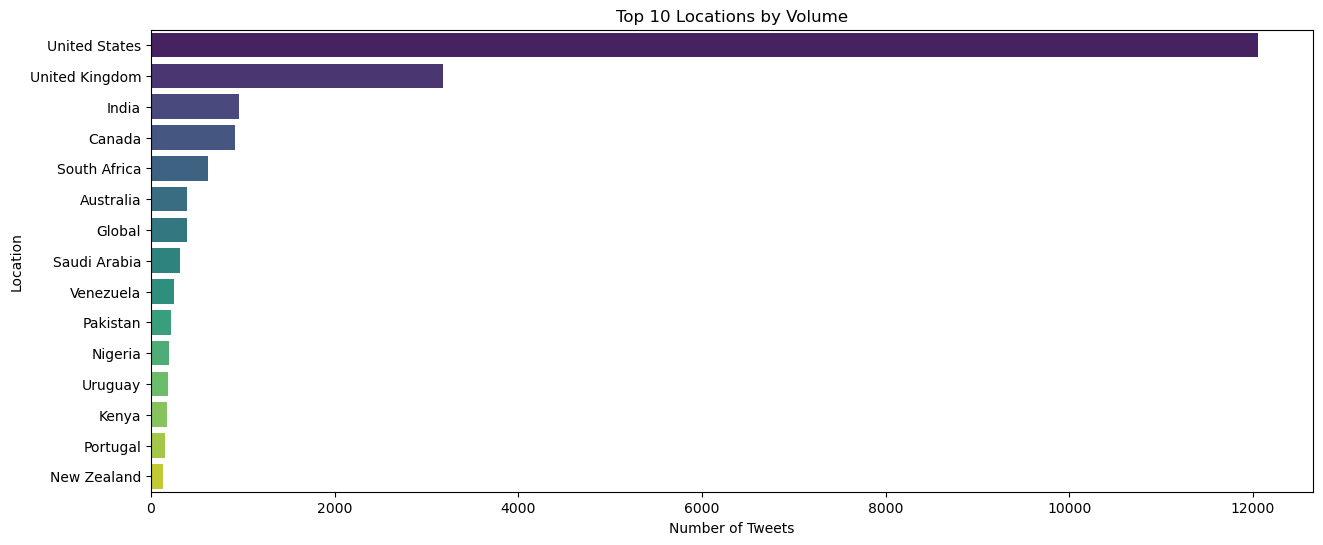

🏆 The Happiest Location is: Portugal (51.3% Positive)
😡 The Angriest Location is: Belgium (43.7% Negative)


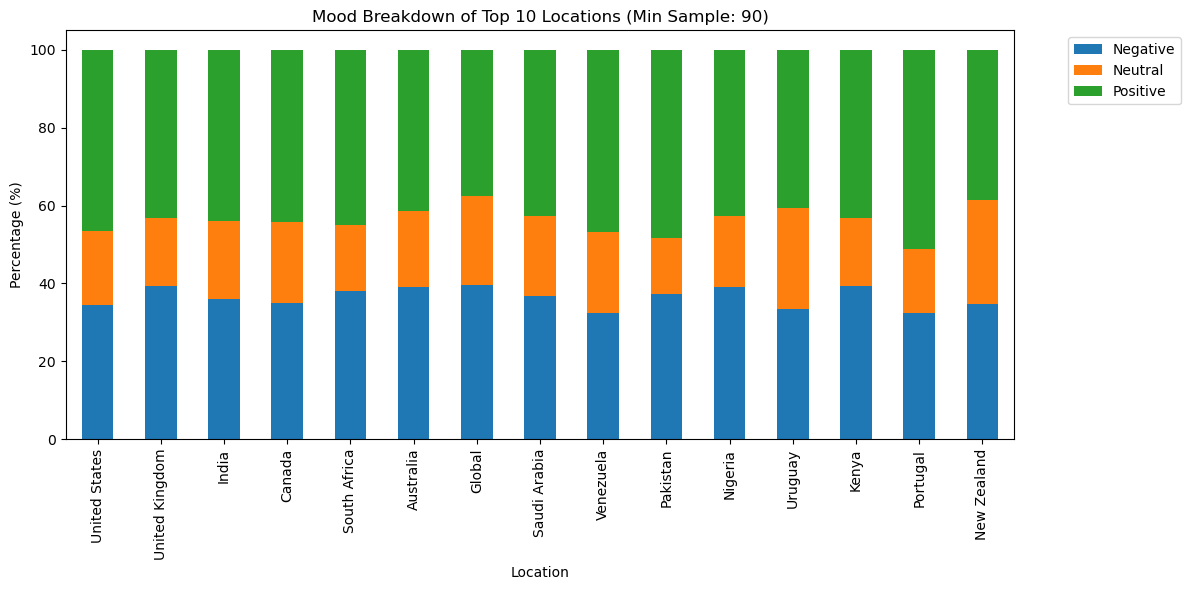

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. SETUP & CONFIGURATION
# ---------------------------------------------------------
# Filter out countries with fewer than 10 tweets to avoid statistical noise
MIN_TWEETS = 90 

# ---------------------------------------------------------
# 2. ANALYSIS: Top 15 Locations
# ---------------------------------------------------------
# We use the 'Location' column as seen in your image
top_locations = df['Location'].value_counts().head(10)

plt.figure(figsize=(15, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top 10 Locations by Volume')
plt.xlabel('Number of Tweets')
plt.show()

# ---------------------------------------------------------
# 3. ANALYSIS: Mood of Each Location (Happiest vs Angriest)
# ---------------------------------------------------------

# Step A: Filter Data
# Only keep locations that have enough data
loc_counts = df['Location'].value_counts()
valid_locs = loc_counts[loc_counts >= MIN_TWEETS].index
df_filtered = df[df['Location'].isin(valid_locs)]

# Step B: Calculate Ratios
# We check 'Location' vs 'Sentiment'
mood_table = pd.crosstab(df_filtered['Location'], df_filtered['Sentiment'])
mood_ratios = mood_table.div(mood_table.sum(1), axis=0) * 100

# Step C: Find Extremes (Happiest / Angriest)
# We handle cases where 'Positive' or 'Negative' might be missing in some rows
try:
    happiest_loc = mood_ratios['Positive'].idxmax()
    happiest_score = mood_ratios.loc[happiest_loc, 'Positive']
    print(f"🏆 The Happiest Location is: {happiest_loc} ({happiest_score:.1f}% Positive)")
except KeyError:
    print("Could not find 'Positive' sentiment to rank.")

try:
    angriest_loc = mood_ratios['Negative'].idxmax()
    angriest_score = mood_ratios.loc[angriest_loc, 'Negative']
    print(f"😡 The Angriest Location is: {angriest_loc} ({angriest_score:.1f}% Negative)")
except KeyError:
    print("Could not find 'Negative' sentiment to rank.")

# 3. Most Neutral (Max Neutral) -> ADDED THIS PART
    neutral_loc = mood_ratios['Neutral'].idxmax()
    neutral_score = mood_ratios.loc[neutral_loc, 'Neutral']
    print(f"😐 Most Neutral Location: {neutral_loc} ({neutral_score:.1f}% Neutral)")

except KeyError as e:
    print(f"Could not find sentiment column: {e}. Check if your labels match 'Positive', 'Negative', 'Neutral'.")

# Step D: Visualization
# Plotting the Top 10 Locations from our previous list
plot_data = mood_ratios.loc[top_locations.index]

# Note: Adjust the color list if you have more than 3 sentiment categories (e.g. Extremely Positive)
plot_data.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title(f'Mood Breakdown of Top 10 Locations (Min Sample: {MIN_TWEETS})')
plt.ylabel('Percentage (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

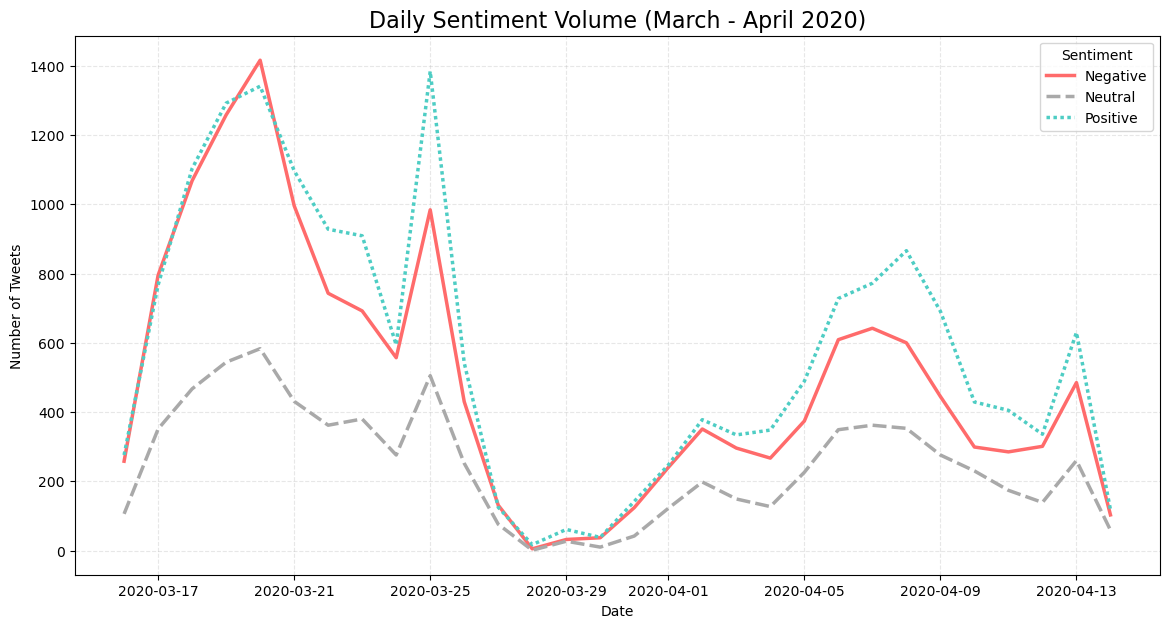

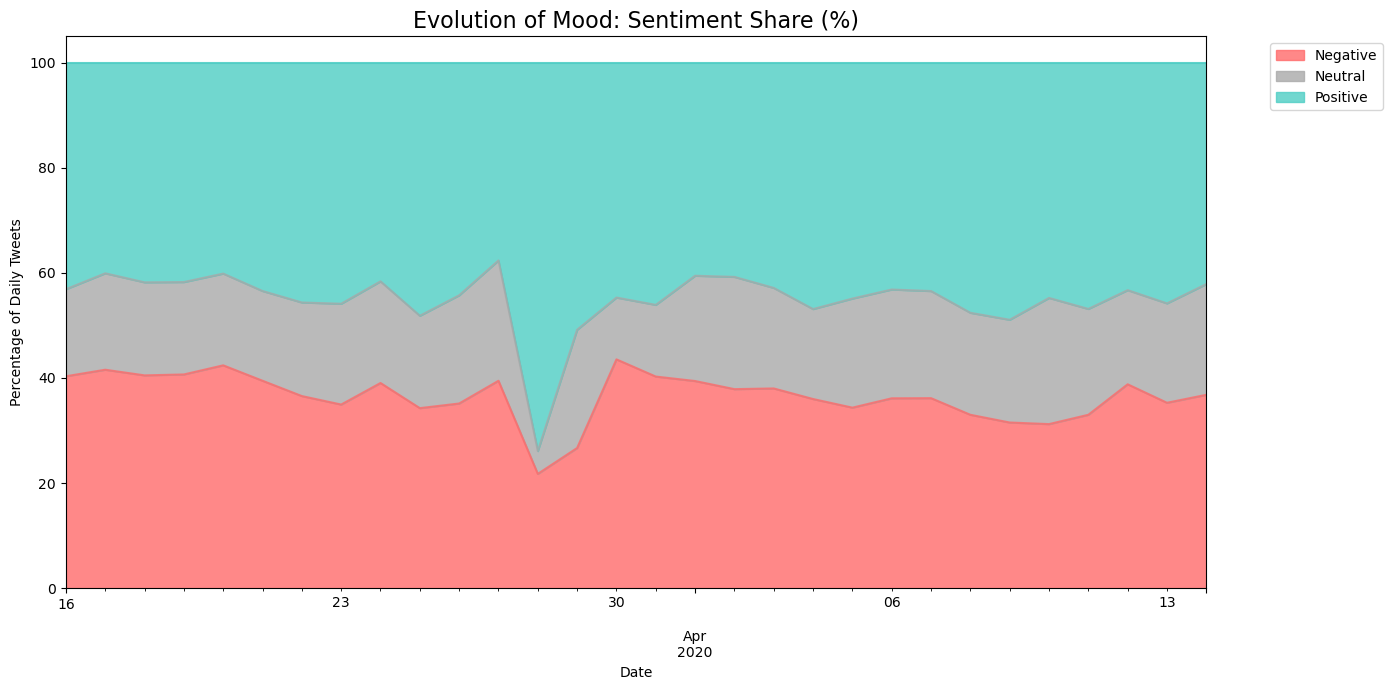

In [73]:
# ANALYSIS: Sentiment Pattern (Positive, Negative, Neutral) Over one month 
# ---------------------------------------------------------

# 1. Prepare the Data
# Ensure TweetAt is a date
df['TweetAt'] = pd.to_datetime(df['TweetAt'], errors='coerce')

# Create the Frequency Table
daily_sentiment = pd.crosstab(df['TweetAt'], df['Sentiment'])

# ---------------------------------------------------------
# CHART 1: The Volume Trend (How loud?)
# ---------------------------------------------------------
plt.figure(figsize=(14, 7))

# Simplified Color Map
# Negative = Red, Neutral = Gray, Positive = Green
custom_colors = {
    'Negative': '#FF6B6B',  # Red
    'Neutral': '#A9A9A9',   # Gray
    'Positive': '#4ECDC4'   # Green
}

sns.lineplot(data=daily_sentiment, palette=custom_colors, linewidth=2.5)

plt.title('Daily Sentiment Volume (March - April 2020)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Sentiment')
plt.show()

# ---------------------------------------------------------
# CHART 2: The Mood Share (Percentage)
# ---------------------------------------------------------
# Calculate percentage per day
daily_ratios = daily_sentiment.div(daily_sentiment.sum(1), axis=0) * 100

# Area Chart
# We create a list of colors that matches the columns in 'daily_ratios'
plot_colors = [custom_colors.get(col, 'blue') for col in daily_ratios.columns]

daily_ratios.plot(kind='area', stacked=True, color=plot_colors, figsize=(14, 7), alpha=0.8)

plt.title('Evolution of Mood: Sentiment Share (%)', fontsize=16)
plt.ylabel('Percentage of Daily Tweets')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [99]:
df['Location'].head(50).value_counts()

Location
United States                24
United Kingdom                4
Canada                        3
India                         2
South Africa                  2
Ketchum                       1
Pakistan                      1
Where The Wild Things Are     1
Sverige                       1
Someplace                     1
Everywhere You Are!           1
southampton soxx xxx          1
Downstage centre              1
Vagabonds                     1
North America                 1
Saudi Arabia                  1
Horningsea                    1
Philippines                   1
Austria                       1
Japan                         1
Name: count, dtype: int64

In [74]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,clean_tweets,processed_tweets
0,3799,48751,United Kingdom,2020-03-16,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,menyrbie phil_gahan chrisitv,"[menyrbi, phil_gahan, chrisitv]"
1,3800,48752,United Kingdom,2020-03-16,advice Talk to your neighbours family to excha...,Positive,advice talk neighbours family exchange phone n...,"[advic, talk, neighbour, famili, exchang, phon..."
2,3801,48753,Vagabonds,2020-03-16,Coronavirus Australia: Woolworths to give elde...,Positive,coronavirus australia: woolworths give elderly...,"[coronaviru, australia, woolworth, give, elder..."
3,3802,48754,NaN,2020-03-16,My food stock is not the only one which is emp...,Positive,"food stock one empty... please, panic, enough ...","[food, stock, one, empti, ..., pleas, panic, e..."
4,3803,48755,NaN,2020-03-16,"Me, ready to go at supermarket during the #COV...",Negative,"me, ready go supermarket #covid19 outbreak. pa...","[readi, go, supermarket, #covid19, outbreak, p..."


In [75]:
#words analysis
import ast
# 1. Safe Loader
# When you load a CSV, lists look like strings "['a', 'b']". 
# This converts them back to real Python lists.
def safe_eval(x):
    try:
        if isinstance(x, str) and x.startswith('['):
            return ast.literal_eval(x)
        return x
    except:
        return []

# Apply the converter
df['processed_tweets_list'] = df['processed_tweets'].apply(safe_eval)

# 2. Calculate Counts
# Flatten the list of lists into one huge list of all words
all_words = [word for sublist in df['processed_tweets_list'] if isinstance(sublist, list) for word in sublist]

total_count = len(all_words)            # Every word counted
unique_count = len(set(all_words))      # Only unique words

print(f"📚 Total Words (Volume): {total_count:,}")
print(f"🔤 Unique Words (Vocabulary): {unique_count:,}")
print(f"📉 You are keeping the top 5,000. That is {5000/unique_count:.1%} of your unique vocabulary.")

📚 Total Words (Volume): 756,306
🔤 Unique Words (Vocabulary): 52,480
📉 You are keeping the top 5,000. That is 9.5% of your unique vocabulary.


In [91]:
# 1. Total tweets covered by the Top 50 locations
total_tweets_top_50 = df['Location'].value_counts().head(50).sum()

print(f"Total Tweets in the Top 50 Locations: {total_tweets_top_50}")

# 2. Total unique locations in the entire dataset
total_unique_locations = df['Location'].nunique()

print(f"Total Unique Locations (Countries) in dataset: {total_unique_locations}")

Total Tweets in the Top 50 Locations: 31074
Total Unique Locations (Countries) in dataset: 5729


In [3]:
cleaned_df= pd.read_csv('Corona_NLP_train_Top50.csv')


In [4]:
test_df= pd.read_csv('Corona_NLP_test_Expanded.csv')

In [8]:
cols_to_drop = [ 'clean_tweets', 'processed_tweets_list']
test_df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

In [12]:
cleaned_df['Sentiment'].value_counts()

Sentiment
Positive    13732
Negative    11496
Neutral      5846
Name: count, dtype: int64

--- Top 50 Locations (Raw Data) ---
Location
United States           17126
United Kingdom           4487
India                    1370
Canada                   1323
South Africa              896
Australia                 569
Saudi Arabia              463
Venezuela                 356
Pakistan                  311
Nigeria                   288
Uruguay                   278
Kenya                     242
Portugal                  234
New Zealand               186
Philippines               186
United Arab Emirates      165
Scotland                  151
Malaysia                  149
Belgium                   149
Brazil                    148
Uganda                    127
Singapore                 120
China                     118
Germany                   111
Ghana                     105
France                     88
Japan                      83
Ireland                    78
Hong Kong                  75
Montenegro                 74
Italy                      70
North West               

C:\Users\moazm\AppData\Local\Temp\ipykernel_24616\1731597978.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


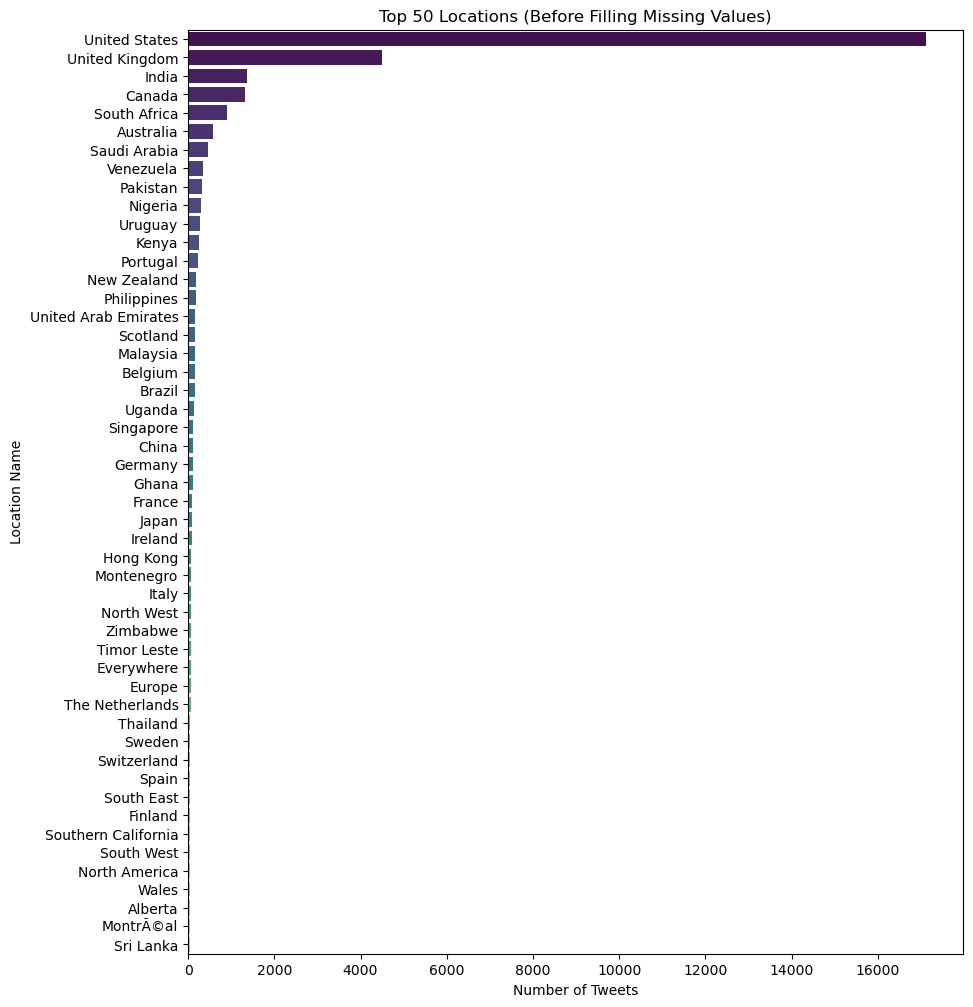

In [98]:
#converting nulls to valid locations
import seaborn as sns
# ---------------------------------------------------------
# Step 1: Calculate Top 50
# ---------------------------------------------------------
# We get the raw counts of every location
top_50_locations = df['Location'].value_counts().head(50)

print("--- Top 50 Locations (Raw Data) ---")
print(top_50_locations)

# ---------------------------------------------------------
# Step 2: Visualize (Bar Chart)
# ---------------------------------------------------------
plt.figure(figsize=(10, 12))  # Tall chart to fit 50 names

# Create a bar plot
sns.barplot(
    y=top_50_locations.index, 
    x=top_50_locations.values, 
    palette='viridis'
)

plt.title('Top 50 Locations (Before Filling Missing Values)')
plt.xlabel('Number of Tweets')
plt.ylabel('Location Name')
plt.show()

In [9]:
cleaned_df.head()
test_df.head()


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,processed_tweets,final_text
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Negative,"['trend', 'new', 'yorker', 'encount', 'empti',...",trend new yorker encount empti supermarket she...
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive,"['find', 'hand', 'sanit', 'fred', 'meyer', 'tu...",find hand sanit fred meyer turn #amazon 97 2 p...
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Positive,"['find', 'protect', 'love', 'one', '#coronaviru']",find protect love one #coronaviru
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative,"['#panic', 'buy', 'hit', '#newyork', 'citi', '...",#panic buy hit #newyork citi anxiou shopper st...
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral,"['#toiletpap', '#dunnypap', '#coronaviru', '#c...",#toiletpap #dunnypap #coronaviru #coronavirusa...


In [ ]:
########## TF-IDF with SVC Linear (Machine Learning model)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ---------------------------------------------------------
# STEP 0: TF-IDF Vectorization (The Setup)
# ---------------------------------------------------------
print("0. Preparing TF-IDF Features...")

# 1. Prepare Training Text
# We need to join the list of words back into a single string for TF-IDF
# Assuming 'df_filtered' is your clean training dataframe with 'processed_tweets'
cleaned_df['final_text'] = cleaned_df['processed_tweets'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

# 2. Initialize the Vectorizer
# max_features=5000: Limits vocabulary to top 5k words (Reduces noise)
# ngram_range=(1,2): captures "not happy" as a phrase, not just "not" and "happy"
vectorizer = TfidfVectorizer(max_features=2798, ngram_range=(1,2))

# 3. Fit & Transform on TRAINING Data
# This creates the "X_tfidf" variable required in Step 1
X_tfidf = vectorizer.fit_transform(cleaned_df['final_text'])

print(f"✅ Vectorizer Fitted. Vocabulary Size: {len(vectorizer.vocabulary_)}")
print(f"   Shape of Training Matrix: {X_tfidf.shape}")

0. Preparing TF-IDF Features...
✅ Vectorizer Fitted. Vocabulary Size: 2798
   Shape of Training Matrix: (31074, 2798)


1. Training Linear SVM on 'cleaned_df'...
✅ Model Trained.

2. Preparing Test Data (Size: 12371)...
3. Cleaning Test Data with 'process_tweet'...
4. Vectorizing...
5. Predicting...

✅ Final Accuracy on Test DF: 78.18%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.79      0.79      4960
     Neutral       0.68      0.67      0.68      2210
    Positive       0.80      0.82      0.81      5201

    accuracy                           0.78     12371
   macro avg       0.76      0.76      0.76     12371
weighted avg       0.78      0.78      0.78     12371



<Figure size 800x600 with 0 Axes>

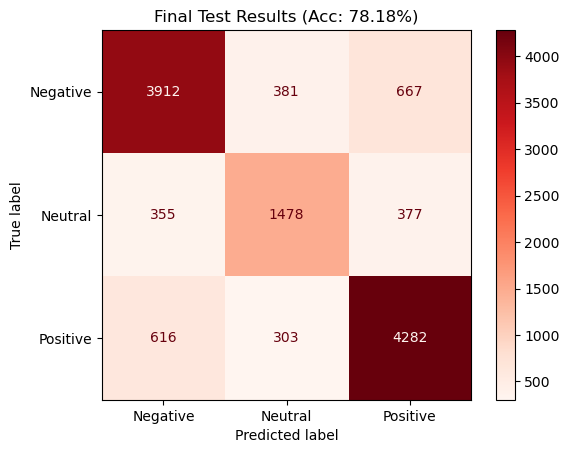

In [29]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------------------------
# STEP 1: Train Linear SVM (on Cleaned Top 50 Data)
# ---------------------------------------------------------
print("1. Training Linear SVM on 'cleaned_df'...")

# Labels from your clean training data
y_train = cleaned_df['Sentiment']

# Train the model
# Assumption: X_tfidf is already created from cleaned_df['processed_tweets']
svm_model = LinearSVC(dual=False, max_iter=1000, random_state=42)
svm_model.fit(X_tfidf, y_train)

print("✅ Model Trained.")

# ---------------------------------------------------------
# STEP 2: Prepare Test Data
# ---------------------------------------------------------
# We use the existing 'test_df' you have loaded
print(f"\n2. Preparing Test Data (Size: {len(test_df)})...")
test_df.dropna(subset=['OriginalTweet'], inplace=True)

# ---------------------------------------------------------
# STEP 3: Clean & Process Test Text
# ---------------------------------------------------------
print("3. Cleaning Test Data with 'process_tweet'...")

# A. Apply YOUR function
test_df['processed_tweets'] = test_df['OriginalTweet'].apply(process_tweet)

# C. Convert list of tokens -> String for TF-IDF
# Example: ['covid', 'bad'] -> "covid bad"
test_df['final_text'] = test_df['processed_tweets'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

# ---------------------------------------------------------
# STEP 4: Vectorize Test Data
# ---------------------------------------------------------
print("4. Vectorizing...")

# CRITICAL: Use .transform() to fit test data into training vocabulary
X_test_final = vectorizer.transform(test_df['final_text'])
y_test_final = test_df['Sentiment']

# ---------------------------------------------------------
# STEP 5: Predict & Evaluate
# ---------------------------------------------------------
print("5. Predicting...")
y_pred_final = svm_model.predict(X_test_final)

acc = accuracy_score(y_test_final, y_pred_final)

print(f"\n✅ Final Accuracy on Test DF: {acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_final))

# Visual Check
cm = confusion_matrix(y_test_final, y_pred_final, labels=svm_model.classes_)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap='Reds', values_format='d')
plt.title(f'Final Test Results (Acc: {acc:.2%})')
plt.show()

In [16]:
#Making predictions and Sentiment Analysis
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. Prediction Function ---
def predict_sentiment_svm(text):
    # A. Clean the text using YOUR function
    tokens = process_tweet(text)
    
    # B. Convert list -> string ("covid bad")
    final_text = ' '.join(tokens)
    
    # C. Vectorize (Transform using the dictionary learned during training)
    # Note: 'vectorizer' must be the one fitted on cleaned_df
    vec = vectorizer.transform([final_text])
    
    # D. Predict
    pred = svm_model.predict(vec)[0]
    
    print(f"Text:       '{text}'")
    print(f"Sentiment:  {pred}")
    print("-" * 30)
    return pred

# --- 2. Similarity Function (TF-IDF Version) ---
def find_similar_tweets_svm(text, top_n=3):
    # A. Process Input
    tokens = process_tweet(text)
    final_text = ' '.join(tokens)
    query_vec = vectorizer.transform([final_text])
    
    # B. Calculate Similarity
    # We compare the input against the Training Matrix (X_tfidf)
    # Assumption: X_tfidf corresponds exactly to cleaned_df rows
    
    # Safety Check: Does X_tfidf exist?
    if 'X_tfidf' not in globals():
        print("⚠️ Error: 'X_tfidf' matrix not found. Please run the training step first.")
        return []

    # Fast Cosine Similarity on Sparse Matrix
    sim_scores = cosine_similarity(query_vec, X_tfidf).flatten()
    
    # C. Get Top N Matches
    top_indices = np.argpartition(sim_scores, -top_n)[-top_n:]
    # Sort descending
    top_indices = top_indices[np.argsort(sim_scores[top_indices])[::-1]]
    
    print("Most Similar Tweets (Keyword Match):")
    for idx in top_indices:
        score = sim_scores[idx]
        # Fetch the original tweet from the training data
        tweet = cleaned_df.iloc[idx]['OriginalTweet']
        print(f"[{score:.3f}] {tweet[:100]}...")

# --- 3. Try it out ---
user_input = "I am scared about the food shortage at the supermarket"

predict_sentiment_svm(user_input)
find_similar_tweets_svm(user_input)

Text:       'I am scared about the food shortage at the supermarket'
Sentiment:  Negative
------------------------------
Most Similar Tweets (Keyword Match):
[0.560] If people do this over imagine when the food shortages start  ...
[0.511] Germany COVID-19 Upadate: Food shortage sparks panic buying. Is there really a food shortage in Germ...
[0.503] FORT HOOD COMMISSARY RESPONDS TO INCREASED DEMAND

https://t.co/M1iKSHBjif

#FortHood #USArm...


In [18]:
my_text="Hello my name is coronavirus"
predict_sentiment_svm(my_text)
find_similar_tweets_svm(my_text)

Text:       'Hello my name is coronavirus'
Sentiment:  Positive
------------------------------
Most Similar Tweets (Keyword Match):
[0.388] Not going to name names, but when this is all done with, I don't think Canadians are going to forget...
[0.375] Well, hello there ?
#COVID?19 #coronavirus #toiletpaper #StayAtHome #poopchallenge https://t.co/8W...
[0.369] #Coronavirus scam alert from @FDICgov : scammers use FDICÂs name and logo, names of actual employee...


In [19]:
#Saving model 
import pickle

# Define filenames
svm_filename = 'model1_svm.pkl'
tfidf_filename = 'model1_tfidf_vectorizer.pkl'

# Save
print("Saving Model 1...")
with open(svm_filename, 'wb') as file:
    pickle.dump(svm_model, file)

with open(tfidf_filename, 'wb') as file:
    pickle.dump(vectorizer, file)

print(f"✅ Model 1 saved as '{svm_filename}' and '{tfidf_filename}'")

Saving Model 1...
✅ Model 1 saved as 'model1_svm.pkl' and 'model1_tfidf_vectorizer.pkl'


In [ ]:
########## TF-IDF with Linear SVC machin elearning model with minimizing features ##########

Training on ALL available records: 31074
1. Vectorizing full dataset...
   Matrix Shape: (31074, 2899)
2. Training Linear SVM on 24859 records...

✅ Full Data Accuracy: 79.13%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.79      0.79      2261
     Neutral       0.71      0.66      0.68      1177
    Positive       0.82      0.85      0.83      2777

    accuracy                           0.79      6215
   macro avg       0.77      0.77      0.77      6215
weighted avg       0.79      0.79      0.79      6215



<Figure size 800x600 with 0 Axes>

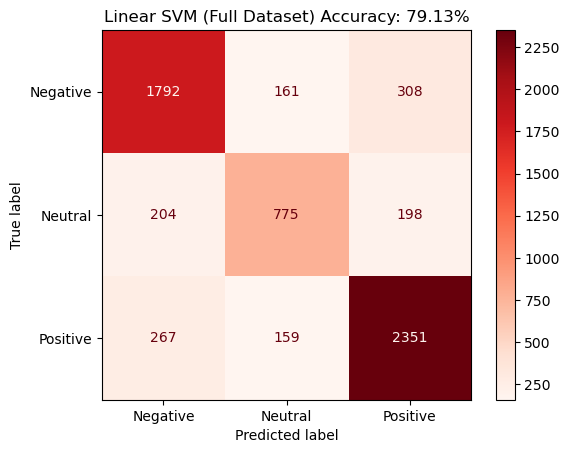

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1: Use the Whole Dataset
# ---------------------------------------------------------
# We simply copy the original df instead of filtering it
df_full_train = cleaned_df.copy()

print(f"Training on ALL available records: {len(df_full_train)}")

# ---------------------------------------------------------
# STEP 2: Prepare Text
# ---------------------------------------------------------
# Convert list of tokens back to string for TF-IDF
df_full_train['final_text'] = df_full_train['processed_tweets'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

# ---------------------------------------------------------
# STEP 3: Vectorization (TF-IDF)
# ---------------------------------------------------------
print("1. Vectorizing full dataset...")

vectorizer_full = TfidfVectorizer(
    min_df=30,                       # Ignore extremely rare words (noise)
    ngram_range=(1, 2),              # Capture "not happy"
    token_pattern=r'(?u)\b[a-zA-Z]+\b' # strict no-numbers rule
)

# Learn from the full data
X_full = vectorizer_full.fit_transform(df_full_train['final_text'])
y_full = df_full_train['Sentiment']

print(f"   Matrix Shape: {X_full.shape}")

# ---------------------------------------------------------
# STEP 4: Train Linear SVM
# ---------------------------------------------------------
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

print(f"2. Training Linear SVM on {X_train.shape[0]} records...")

# Train
svm_full = LinearSVC(dual=False, max_iter=1000, random_state=42)
svm_full.fit(X_train, y_train)

# ---------------------------------------------------------
# STEP 5: Results
# ---------------------------------------------------------
y_pred = svm_full.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n✅ Full Data Accuracy: {acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=svm_full.classes_)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_full.classes_)
disp.plot(cmap='Reds', values_format='d')
plt.title(f'Linear SVM (Full Dataset) Accuracy: {acc:.2%}')
plt.show()

In [112]:
def print_top_words(model, vectorizer, n_top_words=20):
    # 1. Get the actual words from the TF-IDF Vectorizer
    feature_names = vectorizer.get_feature_names_out()
    
    # 2. Get the coefficients (weights) from the LinearSVC
    # shape is (3, n_features) -> 3 rows for Neg, Neu, Pos
    coefs = model.coef_
    
    # 3. Get the class names (so we know which row is which)
    classes = model.classes_
    
    # 4. Loop through each class (Negative, Neutral, Positive)
    for i, class_label in enumerate(classes):
        # Get the row of weights for this specific class
        class_coefficients = coefs[i]
        
        # Sort indices by weight (highest weight = most important)
        # We take the last 'n' indices because argsort sorts low-to-high
        top_indices = class_coefficients.argsort()[-n_top_words:][::-1]
        
        print(f"\n--- Top {n_top_words} words for '{class_label}' ---")
        
        # Print the words and their weights
        top_words = []
        for idx in top_indices:
            word = feature_names[idx]
            weight = class_coefficients[idx]
            top_words.append(f"{word} ({weight:.2f})")
            
        print(", ".join(top_words))

# Run the function
print_top_words(svm_model, vectorizer)


--- Top 20 words for 'Negative' ---
crisi (6.57), kill (4.76), panic (4.75), scam (3.88), hell (3.63), worst (3.58), suffer (3.54), depress (3.48), ass (3.42), fear (3.40), blame (3.36), poor (3.34), shit (3.31), uncertain (3.26), stupid (3.25), threat (3.25), abus (3.21), disgust (3.21), stop (3.20), dead (3.20)

--- Top 20 words for 'Neutral' ---
help fight (2.20), pleas stop (2.10), consum good (1.57), shortag food (1.47), coronaviru viru (1.32), back normal (1.27), bureau (1.19), stockup (1.14), layoff (1.12), ft (1.10), pleas help (1.10), devic (1.08), task forc (1.07), put risk (1.07), essenti good (1.06), litr (1.05), help coronaviru (1.04), diagnos (1.03), wash hand (1.01), properti price (1.00)

--- Top 20 words for 'Positive' ---
best (5.12), great (4.75), help (4.56), free (4.48), thank (4.24), safe (4.13), bonu (4.06), friend (3.94), support (3.90), like (3.90), super (3.83), relief (3.81), enjoy (3.78), confid (3.71), pleas (3.70), growth (3.68), better (3.60), love (3.52

In [80]:
from sklearn.metrics.pairwise import cosine_similarity
# --- 1. Define the Prediction Function ---
def predict_tfidf(text, model, vectorizer):
    # Transform text to numbers
    vec = vectorizer.transform([text])
    # Predict
    pred = model.predict(vec)[0]
    return pred

# --- 2. Define the Similarity Function (The "Hard" Part) ---
def get_similar_tweets_tfidf(text, vectorizer, tfidf_matrix, df_source, top_n=3):
    # Convert input to vector
    query_vec = vectorizer.transform([text])
    
    # Calculate similarity against ALL 40,000+ tweets
    # (LinearSVC doesn't store the matrix, so we use the X_tfidf we created during training)
    similarity_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    # Get indices of top matches (sorted descending)
    # We use argpartition for speed (faster than full sort)
    top_indices = np.argpartition(similarity_scores, -top_n)[-top_n:]
    
    # Sort them nicely by exact score
    top_indices = top_indices[np.argsort(similarity_scores[top_indices])[::-1]]
    
    # Return results
    results = []
    for idx in top_indices:
        score = similarity_scores[idx]
        tweet = df_source.iloc[idx]['OriginalTweet'] # Or 'clean_tweets'
        results.append((score, tweet))
        
    return results

# --- 3. Run Inference ---
user_input = "I have caught a flu, i'm afraid it's the new coronavirus"

# A. Prediction
print(f"Input: {user_input}")
sentiment = predict_tfidf(user_input, svm_model, vectorizer)
print(f"Predicted Sentiment: {sentiment}")

# B. Similarity
print("\nMost Similar Tweets in Dataset:")
similar_tweets = get_similar_tweets_tfidf(user_input, vectorizer, X_tfidf, cleaned_df)
for score, tweet in similar_tweets:
    print(f"[{score:.2f}] {tweet[:100]}...") # Printing first 100 chars

Input: I have caught a flu, i'm afraid it's the new coronavirus
Predicted Sentiment: Negative

Most Similar Tweets in Dataset:
[0.37] workers afraid and families afraid for them for good reason This is devastating and it won t be the ...
[0.33] I caught the swine flu while in graduate school. Spent a month bed ridden. Millions caught it around...
[0.30] New data finds younger consumers are least afraid of #COVID19 and most eager to go out: https://t.co...


In [124]:
# ---------------------------------------------------------
# STEP 6: Interactive Custom Test
# ---------------------------------------------------------

def predict_custom_tweet(text):
    # 1. Clean the text using your existing function
    # (Assuming 'process_tweet' is the function you used in Step 3)
    processed_list = process_tweet(text) 
    
    # Join list back to string, just like you did for the dataframe
    clean_text = ' '.join(processed_list)
    
    # 2. Transform using the ALREADY TRAINED vectorizer
    # We use transform() so it fits the matrix shape exactly
    vectorized_text = vectorizer.transform([clean_text])
    
    # 3. Predict
    prediction = svm_model.predict(vectorized_text)
    
    # Optional: Get "Decision Function" score (Distance from the separator line)
    # This isn't a percentage, but higher numbers mean the model is more confident.
    score = svm_model.decision_function(vectorized_text)
    
    return prediction[0], score

# --- Loop ---
print("\n--- Interactive Mode ---")
while True:
    user_input = input("\nEnter a tweet (or 'q' to quit): ")
    if user_input.lower() == 'q':
        break
    
    pred, score = predict_custom_tweet(user_input)
    
    print(f"Prediction:  {pred}")
    print(f"Model Score: {score}") 
    # Note: Score > 0 usually means Positive/one class, < 0 means the other. 
    # Since you have 3 classes (Pos/Neg/Neu), it will show scores for each class.


--- Interactive Mode ---



Enter a tweet (or 'q' to quit):  i love pancakes


Prediction:  Positive
Model Score: [[-3.63825391 -1.38159442  2.69682409]]



Enter a tweet (or 'q' to quit):  q


In [ ]:
############ Glove with LSTM (deeplearning) #############

In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer

# 1. Setup the tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(cleaned_df['clean_tweets']) 

# 2. Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(cleaned_df['clean_tweets'])

# 3. Define Vocabulary Size
vocab_size = len(tokenizer.word_index) + 1

In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Max length of a tweet (you can choose this based on your data distribution)
max_length = 100 

X_data = pad_sequences(sequences, maxlen=max_length, padding='post')

In [32]:
embedding_dim = 100 # Must match the GloVe file you downloaded (e.g., 50d, 100d, 200d)
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Open the GloVe file
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0] # The word itself
        
        # If the word is in our data's vocabulary
        if word in tokenizer.word_index:
            idx = tokenizer.word_index[word]
            # Convert the rest of the line to a numpy array (the vector)
            embedding_matrix[idx] = np.array(values[1:], dtype='float32')

print(f"Embedding Matrix Shape: {embedding_matrix.shape}")

Embedding Matrix Shape: (49259, 100)


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Define parameters based on your previous steps
vocab_size = 49259     # From your embedding matrix shape
embedding_dim = 100    # From GloVe
max_length = 100       # The length you chose for padding

model = Sequential()

# 1. The Embedding Layer (The Dictionary)
# We load our 'embedding_matrix' into the weights argument
model.add(Embedding(input_dim=vocab_size, 
                    output_dim=embedding_dim, 
                    weights=[embedding_matrix], 
                    input_length=max_length, 
                    trainable=False)) 

# 2. The LSTM Layer (The Reader)
# Bidirectional lets it read forwards and backwards for better context
model.add(Bidirectional(LSTM(units=128, return_sequences=False)))
model.add(Dropout(0.2)) # Prevents overfitting

# 3. Dense Layers (The Decision Maker)
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

# 4. Output Layer
# 3 units for Negative, Neutral, Positive
model.add(Dense(3, activation='softmax')) 

# Compile the model
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()


C:\Users\moazm\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │       4,925,900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,925,900 (18.79 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,925,900 (18.79 MB)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Encode the target (Sentiment)
label_encoder = LabelEncoder()
y_data = label_encoder.fit_transform(cleaned_df['Sentiment']) 
# This turns 'Negative'->0, 'Neutral'->1, 'Positive'->2 (order may vary)

# 2. Split into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 24859
Testing samples: 6215


In [35]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.6489 - loss: 0.8012 - val_accuracy: 0.7022 - val_loss: 0.7154
Epoch 2/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.7139 - loss: 0.6863 - val_accuracy: 0.7216 - val_loss: 0.6781
Epoch 3/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.7469 - loss: 0.6263 - val_accuracy: 0.7397 - val_loss: 0.6350
Epoch 4/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7695 - loss: 0.5730 - val_accuracy: 0.7633 - val_loss: 0.6015
Epoch 5/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.7957 - loss: 0.5218 - val_accuracy: 0.7712 - val_loss: 0.5790
Epoch 6/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.8179 - loss: 0.4713 - val_accuracy: 0.7776 - val_loss: 0.5795
Epoch 7/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.8383 - loss: 0.4262 - val_accuracy: 0.7831 - val_loss: 0.5792
Epoch 8/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.8599 - loss: 0.3745 - 

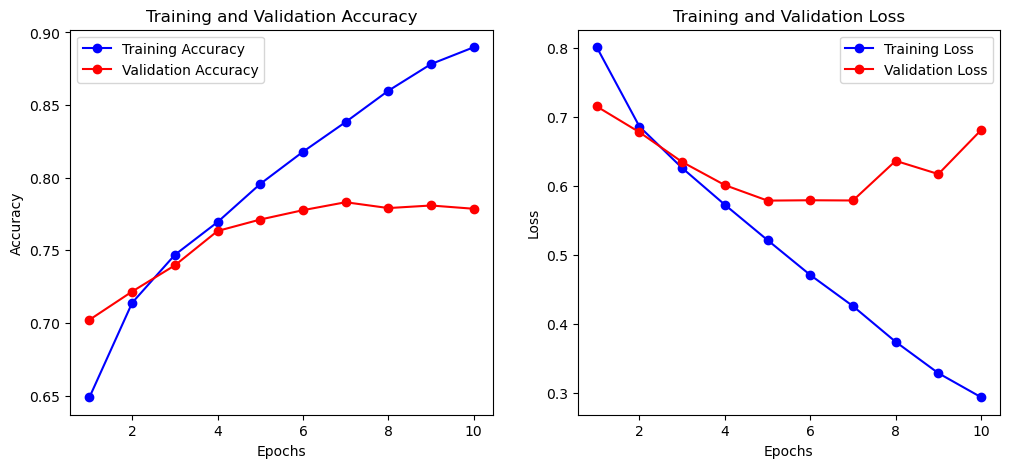

In [36]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_training_history(history)

In [37]:
def predict_sentiment(text):
    # 1. Tokenize and Pad the new text
    # Note: We use 'clean_tweets' logic here. If you had a specific cleaning function, apply it first.
    sequence = tokenizer.texts_to_sequences([text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post')

    # 2. Predict
    prediction_prob = model.predict(padded_sequence)
    prediction_class = np.argmax(prediction_prob, axis=1)[0]
    
    # 3. Decode the result
    sentiment_label = label_encoder.inverse_transform([prediction_class])[0]
    confidence = prediction_prob[0][prediction_class]

    print(f"Text:       '{text}'")
    print(f"Sentiment:  {sentiment_label} ({confidence:.2%} confidence)")
    print("-" * 30)

# --- Try it out! ---
predict_sentiment("The supermarket shelves are completely empty, this is scary.")
predict_sentiment("I am spending time with my family at home, it is quite nice.")
predict_sentiment("The virus counts are remaining stable today.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
Text:       'The supermarket shelves are completely empty, this is scary.'
Sentiment:  Negative (90.41% confidence)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Text:       'I am spending time with my family at home, it is quite nice.'
Sentiment:  Positive (99.23% confidence)
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Text:       'The virus counts are remaining stable today.'
Sentiment:  Positive (83.87% confidence)
------------------------------


In [23]:
predict_sentiment("coronavirus is good for economics, but bad for humans")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Text:       'coronavirus is good for economics, but bad for humans'
Sentiment:  Negative (57.94% confidence)
------------------------------


In [38]:
# Save Keras Model
model2_filename = 'model2_lstm_glove.keras'
tokenizer2_filename = 'model2_tokenizer_glove.pkl'

print("Saving Model 2...")
# 1. Save Keras Model (Use .keras, NOT pickle)
# Ensure your model variable is named 'lstm_glove_model' (or whatever you called it)
if 'lstm_glove_model' in globals():
    lstm_glove_model.save(model2_filename)

# 2. Save Tokenizer
with open(tokenizer2_filename, 'wb') as file:
    # Ensure this is the tokenizer used for GloVe
    pickle.dump(tokenizer, file) 

print(f"✅ Model 2 saved as '{model2_filename}' and '{tokenizer2_filename}'")

Saving Model 2...
✅ Model 2 saved as 'model2_lstm_glove.keras' and 'model2_tokenizer_glove.pkl'


In [39]:
############### Trying word2Vec (Logistic Regression ) #################

In [40]:
import ast
from gensim.models import Word2Vec

# 1. The Fix: Convert "Stringified Lists" back to Real Lists
# We apply this ONLY if the data is currently a string (to avoid errors if it's already fixed)
def safe_eval(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

# Apply the fix to your column
cleaned_df['processed_tweets'] = cleaned_df['processed_tweets'].apply(safe_eval)

# 2. Verify the Fix
# Check the type of the first row. It MUST say <class 'list'>, not <class 'str'>
print(f"Type of data in first row: {type(cleaned_df['processed_tweets'].iloc[0])}")

# 3. Retrain Word2Vec with the fixed data
# Now 'sentences' will be a list of lists, which is what Word2Vec needs
sentences = cleaned_df['processed_tweets'].tolist()

w2v_model = Word2Vec(sentences, 
                     vector_size=100, 
                     window=5, 
                     min_count=1, 
                     workers=4)

# 4. Check the vocabulary again
# You should now see full words like 'advic', 'store', 'panic'
print("Corrected Vocabulary:", list(w2v_model.wv.index_to_key)[:10])

Type of data in first row: <class 'list'>
Corrected Vocabulary: ['#coronaviru', '19', 'covid', 'price', 'store', '\x92', 'food', 'supermarket', 'groceri', 'peopl']


In [41]:
print("New Vocabulary (Words):", list(w2v_model.wv.index_to_key)[:10])

New Vocabulary (Words): ['#coronaviru', '19', 'covid', 'price', 'store', '\x92', 'food', 'supermarket', 'groceri', 'peopl']


In [42]:
# Initialize the matrix with zeros
embedding_matrix = np.zeros((vocab_size, 100))

# Fill the matrix
for word, i in tokenizer.word_index.items():
    # Check if the word exists in the Word2Vec vocabulary
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
    # Words not in Word2Vec will remain as zeros (padding/rare words)

print(f"Custom Embedding Matrix Shape: {embedding_matrix.shape}")

Custom Embedding Matrix Shape: (49259, 100)


In [43]:
# Define the function that turns a list of words into a single vector
def get_mean_vector(word_list, model):
    # 1. Filter: Keep only words that exist in the Word2Vec vocabulary
    valid_vectors = [model.wv[word] for word in word_list if word in model.wv]
    
    # 2. Average: If we found valid words, calculate the mean
    if len(valid_vectors) > 0:
        return np.mean(valid_vectors, axis=0)
    
    # 3. Handle Empty: If no words matched, return a vector of zeros
    else:
        return np.zeros(model.vector_size)

print("Feature Extraction function is ready.")

Feature Extraction function is ready.


In [44]:
# --- 1. Prepare Training Data (Full 30k+ records) ---
# This is the custom function to fix the "String vs List" issue
def convert_to_list(text):
    try:
        # If it's a string like "['a', 'b']", turn it into a real list ['a', 'b']
        if isinstance(text, str):
            return ast.literal_eval(text)
        # If it's already a list, just return it
        return text
    except:
        return [] # Return empty if something is broken
print("Processing Training Data...")
# Create Features (X)
X_train_full = np.array([get_mean_vector(x, w2v_model) for x in cleaned_df['processed_tweets']])
# Create Target (y)
y_train_full = label_encoder.fit_transform(cleaned_df['Sentiment'])

# --- 2. Prepare Test Data (The separate 12k records) ---
# Make sure your test_df has gone through the same "string-to-list" fix we did earlier!
print("Processing Test Data...")
# Check if test_df exists, replace 'test_df' with your actual dataframe name
if 'test_df' in locals():
    # Ensure the column is a list, not a string
    test_df['processed_tweets_fixed'] = test_df['processed_tweets'].apply(convert_to_list) # Using the function we wrote earlier
    
    # Create Features (X)
    X_test_full = np.array([get_mean_vector(x, w2v_model) for x in test_df['processed_tweets_fixed']])
    # Create Target (y)
    y_test_full = label_encoder.transform(test_df['Sentiment']) # Use 'transform', not 'fit_transform'
    
    print(f"Training Shape: {X_train_full.shape}")
    print(f"Testing Shape:  {X_test_full.shape}")
else:
    print("Error: Please make sure your test dataframe is loaded and named 'test_df'")

Processing Training Data...
Processing Test Data...
Training Shape: (31074, 100)
Testing Shape:  (12371, 100)


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Initialize the Model
# solver='lbfgs' is standard for multiclass problems
log_reg = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')

# 2. Train on the FULL training set
print("Training model on full dataset...")
log_reg.fit(X_train_full, y_train_full)

# 3. Predict on the separate TEST set
print("Evaluatiing on test dataset...")
y_pred_test = log_reg.predict(X_test_full)

# 4. Show Results
print("\n--- Final Test Set Results ---")
print(classification_report(y_test_full, y_pred_test, target_names=label_encoder.classes_))

Training model on full dataset...


C:\Users\moazm\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Evaluatiing on test dataset...

--- Final Test Set Results ---
              precision    recall  f1-score   support

    Negative       0.62      0.58      0.60      4960
     Neutral       0.52      0.31      0.39      2210
    Positive       0.59      0.72      0.65      5201

    accuracy                           0.59     12371
   macro avg       0.57      0.54      0.54     12371
weighted avg       0.59      0.59      0.58     12371



In [47]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. Helper: Text Preprocessing for W2V ---
def prepare_input_w2v(text):
    # Basic cleaning to match your W2V training style
    return text.lower().split()

# --- 2. Helper: Get Average Vector ---
def get_mean_vector(word_list, model):
    # Only get vectors for words that exist in your W2V model
    valid_vectors = [model.wv[word] for word in word_list if word in model.wv]
    
    if len(valid_vectors) > 0:
        return np.mean(valid_vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

# --- 3. Prediction Function (Logistic Regression) ---
def predict_w2v_lr(text, w2v_model, lr_model):
    # 1. Process
    tokens = prepare_input_w2v(text)
    
    # 2. Vectorize (Average) & Reshape for prediction
    vector = get_mean_vector(tokens, w2v_model).reshape(1, -1)
    
    # 3. Predict
    pred_class = lr_model.predict(vector)[0]
    
    # 4. Return Label (Decode if you have label_encoder)
    if 'label_encoder' in globals():
        return label_encoder.inverse_transform([pred_class])[0]
    return pred_class

# --- 4. Similarity Function ---
def get_similar_tweets_w2v(text, w2v_model, feature_matrix, df_source, top_n=3):
    # 1. Vectorize Input
    tokens = prepare_input_w2v(text)
    input_vec = get_mean_vector(tokens, w2v_model).reshape(1, -1)
    
    # 2. Compare against the Dataset Matrix
    sim_scores = cosine_similarity(input_vec, feature_matrix).flatten()
    
    # 3. Sort & Extract
    top_indices = sim_scores.argsort()[-top_n:][::-1]
    
    results = []
    for idx in top_indices:
        score = sim_scores[idx]
        # Fetch the original text from your cleaned_df
        # Note: Change 'OriginalTweet' to 'Text' if your column name is different
        tweet = df_source.iloc[idx]['OriginalTweet'] 
        results.append((score, tweet))
        
    return results

# --- 5. Run Inference (Using cleaned_df) ---
print("\n--- Model 3: Word2Vec + Logistic Regression ---")
user_input = "I am scared about the food shortage"

# A. Prepare the Feature Matrix from cleaned_df (Run this once)
# We need to vectorize all tweets in cleaned_df to search through them
if 'X_w2v_average' not in locals():
    print("Vectorizing cleaned_df for similarity search...")
    # Assuming 'processed_tweets' contains lists of tokens ['i', 'am', 'happy'...]
    X_w2v_average = np.array([get_mean_vector(x, w2v_model) for x in cleaned_df['processed_tweets']])
    print(f"Matrix Ready. Shape: {X_w2v_average.shape}")

# B. Execute Prediction
if 'log_reg' in locals() and 'w2v_model' in locals():
    # 1. Sentiment
    pred_lr = predict_w2v_lr(user_input, w2v_model, log_reg)
    print(f"Predicted Sentiment: {pred_lr}")

    # 2. Similarity (Passing cleaned_df and the matrix we just built)
    similar_w2v = get_similar_tweets_w2v(user_input, w2v_model, X_w2v_average, cleaned_df)
    
    print("\nMost Similar Tweets (Semantic Average):")
    for score, tweet in similar_w2v:
        print(f"[{score:.4f}] {tweet}")
else:
    print("Error: Models (log_reg, w2v_model) not found in memory.")


--- Model 3: Word2Vec + Logistic Regression ---
Vectorizing cleaned_df for similarity search...
Matrix Ready. Shape: (31074, 100)
Predicted Sentiment: Negative

Most Similar Tweets (Semantic Average):
[0.9351] We have enough food, assures PM
https://t.co/hSHap8C7tP  https://t.co/hSHap8C7tP
[0.9341] Don t forget to stock up your pet food
[0.9293] During a time when thousands are stocking up on food and essentials, the shelves at food banks in the Peterborough area seem to be dwindling in supplies. But Kawartha Food Share says there is no need to panic. 
https://t.co/AMA9MtXxKy


In [48]:
# Define filenames
lr_filename = 'model3_logreg.pkl'
w2v_filename = 'model3_word2vec.model'

print("Saving Model 3...")
# 1. Save Logistic Regression
if 'log_reg' in globals():
    with open(lr_filename, 'wb') as file:
        pickle.dump(log_reg, file)

# 2. Save Gensim Word2Vec (Gensim has its own save method)
if 'w2v_model' in globals():
    w2v_model.save(w2v_filename)

print(f"✅ Model 3 saved as '{lr_filename}' and '{w2v_filename}'")

Saving Model 3...
✅ Model 3 saved as 'model3_logreg.pkl' and 'model3_word2vec.model'


In [49]:
############### Trying word2Vec (LSTM neural network ) #################

In [50]:
# 1. Setup the Tokenizer
# We join the lists back into strings just for the Tokenizer to learn the vocabulary
texts_train = [' '.join(x) for x in cleaned_df['processed_tweets']]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts_train)
vocab_size = len(tokenizer.word_index) + 1

# 2. Convert Text to Sequences
# Train Data
sequences_train = tokenizer.texts_to_sequences(texts_train)
X_train_seq = pad_sequences(sequences_train, maxlen=100, padding='post')

# Test Data (Use the separate Test DF)
# We assume test_df['processed_tweets_fixed'] exists from previous steps
texts_test = [' '.join(x) for x in test_df['processed_tweets_fixed']]
sequences_test = tokenizer.texts_to_sequences(texts_test)
X_test_seq = pad_sequences(sequences_test, maxlen=100, padding='post')

# 3. Prepare Targets
y_train_seq = label_encoder.fit_transform(cleaned_df['Sentiment'])
y_test_seq = label_encoder.transform(test_df['Sentiment'])

print(f"Train Input Shape: {X_train_seq.shape}")
print(f"Test Input Shape: {X_test_seq.shape}")

Train Input Shape: (31074, 100)
Test Input Shape: (12371, 100)


In [51]:
# Create the matrix
embedding_matrix = np.zeros((vocab_size, 100)) # 100 is your W2V vector size

# Fill it
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
    # If not found, it remains zeros

print(f"Embedding Matrix Ready. Shape: {embedding_matrix.shape}")

Embedding Matrix Ready. Shape: (39112, 100)


In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

model = Sequential()

# 1. Embedding Layer (FIXED: Unfrozen)
model.add(Embedding(input_dim=vocab_size, 
                    output_dim=100, 
                    weights=[embedding_matrix], 
                    input_length=100, 
                    trainable=True)) # <--- Changed to True to break the 64% limit

# 2. LSTM Layer (FIXED: Higher Dropout)
model.add(Bidirectional(LSTM(128, return_sequences=False)))
model.add(Dropout(0.4)) # <--- Increased to 0.4 to stop Overfitting (Red line flatlining)

# 3. Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4)) # <--- Increased to 0.4
model.add(Dense(3, activation='softmax')) # 3 classes: Neg, Neu, Pos

# 4. Compile (FIXED: Lower Learning Rate)
# Replaced default 'adam' with custom rate 0.0001
optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer, 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# 5. Train (FIXED: Reduced Epochs)
print("Starting Optimized LSTM Training...")
history = model.fit(X_train_seq, y_train_seq, 
                    epochs=8, # Stopped at 8 (Where your previous model peaked)
                    batch_size=32, 
                    validation_data=(X_test_seq, y_test_seq))

Starting Optimized LSTM Training...
Epoch 1/8


C:\Users\moazm\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


255/972 ━━━━━━━━━━━━━━━━━━━━ 1:06 93ms/step - accuracy: 0.4171 - loss: 1.0645

KeyboardInterrupt: 

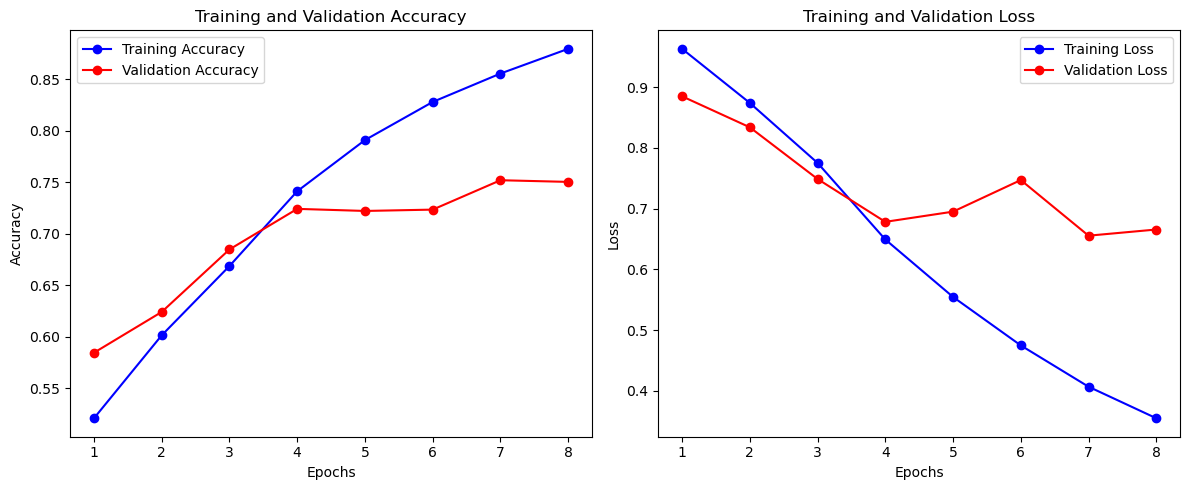

In [55]:
def plot_training_history(history):
    # Extract data from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Create a figure with two subplots
    plt.figure(figsize=(12, 5))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run the function
# Ensure you have a variable named 'history' from your model.fit() step
if 'history' in locals():
    plot_training_history(history)
else:
    print("No history object found. Make sure you have trained the model first!")

In [60]:
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- 1. Helper: Vectorize Function (Matches your W2V Logic) ---
def get_mean_vector(word_list, w2v_model):
    # This creates the "Semantic Average" of a tweet
    valid_vectors = [w2v_model.wv[word] for word in word_list if word in w2v_model.wv]
    if len(valid_vectors) > 0:
        return np.mean(valid_vectors, axis=0)
    else:
        return np.zeros(w2v_model.vector_size)

# --- 2. Prepare the Database for Search (Run Once) ---
# We need a matrix of vectors for every tweet in cleaned_df to compare against
if 'dataset_vectors' not in locals():
    print("Vectorizing entire dataset for similarity search... (This may take a moment)")
    # Assuming 'processed_tweets' is the list of words: ['i', 'am', 'happy']
    dataset_vectors = np.array([get_mean_vector(x, w2v_model) for x in cleaned_df['processed_tweets']])
    print(f"Database Ready. Shape: {dataset_vectors.shape}")

# --- 3. The Main Function ---
def predict_and_recommend(input_text, num_similar=3):
    # --- A. SENTIMENT PREDICTION (LSTM) ---
    
    # 1. Clean & Tokenize
    # Note: Ideally, use the same cleaning function you used for 'processed_tweets'
    cleaned_input = input_text.lower().split() 
    
    # 2. Sequence & Pad (The LSTM expects numbers, not words)
    # We treat the input as a list of strings for texts_to_sequences
    seq = tokenizer.texts_to_sequences([' '.join(cleaned_input)])
    padded_seq = pad_sequences(seq, maxlen=100, padding='post')
    
    # 3. Predict with LSTM
    pred_probs = model.predict(padded_seq, verbose=0)
    pred_class_idx = np.argmax(pred_probs)
    
    # 4. Decode Label
    sentiment = label_encoder.inverse_transform([pred_class_idx])[0]
    confidence = np.max(pred_probs) * 100
    
    # --- B. SIMILAR TWEETS (Word2Vec Cosine Similarity) ---
    
    # 1. Vectorize the input (Get the average vector of the input words)
    input_vector = get_mean_vector(cleaned_input, w2v_model).reshape(1, -1)
    
    # 2. Calculate Cosine Similarity against the whole dataset
    similarities = cosine_similarity(input_vector, dataset_vectors)
    
    # 3. Get indices of the highest scores
    # flatten() is needed because similarity returns shape (1, N)
    top_indices = similarities[0].argsort()[-num_similar:][::-1]
    
    # --- OUTPUT ---
    print(f"\nUser Input: '{input_text}'")
    print(f"Predicted Sentiment (LSTM): {sentiment} ({confidence:.2f}%)")
    print("-" * 30)
    print(f"Top {num_similar} Similar Tweets (Semantic Match):")
    
    for idx in top_indices:
        # Use 'OriginalTweet' to show the user the readable text
        original_tweet = cleaned_df.iloc[idx]['OriginalTweet'] 
        score = similarities[0][idx]
        print(f"- [Score: {score:.4f}] {original_tweet}")

# --- 4. Test It ---
user_input = "It's so bad to catch a flu"
predict_and_recommend(user_input)


User Input: 'It's so bad to catch a flu'
Predicted Sentiment (LSTM): Positive (37.27%)
------------------------------
Top 3 Similar Tweets (Semantic Match):
- [Score: 0.9818] @TheLastLeg #IsItOk that this how I imagine it would be watching you all just before the end of the world...#coronavirus didnÂt come here to fuck spiders #StaySafeStayHome #StopHoarding and who has the amazing laugh?
- [Score: 0.9781] If HEB had a FAST PASS like six flags, I would totally buy one just so I donÂt have to stand in this dang line. Man this whole thing is a rollercoaster. See what I did there?  #sixflags #COVID?19 #beatcorona #coronavirus #COVID19 #AustinTx #austin #Texas #heb #toiletpaper
- [Score: 0.9770] #CoronavirusOutbreak #Covid_19 #CoronavirusPandemic #Coronavirussouthafrica #CoronavirusShutdown Ppl should stock up food&amp; stay home. IÂm so scared??What is happening in Hong Kong really scared me?I seriously feel like this is the end of the world? Corona virus ? https://t.co/yaKUvGRDu0


In [ ]:
##def predict_and_recommend(input_text, num_similar=3):
    # --- A. SENTIMENT PREDICTION ---
    
    # 1. Clean the input (Use the same cleaning steps you used for training)
    # simple split used here, but ideally apply your specific cleaning function
    cleaned_input = input_text.lower().split() 
    
    # 2. Tokenize & Pad (Prepare for LSTM)
    seq = tokenizer.texts_to_sequences([' '.join(cleaned_input)])
    padded_seq = pad_sequences(seq, maxlen=100, padding='post')
    
    # 3. Predict
    pred_probs = model.predict(padded_seq, verbose=0)
    pred_class_idx = np.argmax(pred_probs)
    sentiment = label_encoder.inverse_transform([pred_class_idx])[0]
    confidence = np.max(pred_probs) * 100
    
    # --- B. SIMILAR TWEETS (Using Word2Vec) ---
    
    # 1. Vectorize the input using W2V
    input_vector = get_sentence_vector(cleaned_input).reshape(1, -1)
    
    # 2. Calculate Cosine Similarity against all tweets
    similarities = cosine_similarity(input_vector, dataset_vectors)
    
    # 3. Get top N indices
    # We flatten [0] because cosine_similarity returns shape (1, n_samples)
    top_indices = similarities[0].argsort()[-num_similar:][::-1]
    
    # --- OUTPUT ---
    print(f"\nUser Input: '{input_text}'")
    print(f"Predicted Sentiment: {sentiment} ({confidence:.2f}%)")
    print("-" * 30)
    print(f"Top {num_similar} Similar Tweets found in Database:")
    
    for idx in top_indices:
        original_tweet = cleaned_df.iloc[idx]['Text'] # Assuming 'Text' is your raw column
        score = similarities[0][idx]
        print(f"- [Score: {score:.4f}] {original_tweet}")

# --- TEST IT ---
user_input = "I am so happy with this service"
predict_and_recommend(user_input)

In [61]:
# Define filenames
lstm_filename = 'model4_lstm_finetuned.keras'
tokenizer_filename = 'model4_tokenizer.pkl'
encoder_filename = 'model4_label_encoder.pkl'

print("Saving Model 4...")

# 1. Save LSTM (Keras format)
# Ensure your fine-tuned model variable is named 'model'
model.save(lstm_filename)

# 2. Save Tokenizer
with open(tokenizer_filename, 'wb') as file:
    pickle.dump(tokenizer, file)

# 3. Save Label Encoder (to turn 0,1,2 back into 'Negative', etc.)
with open(encoder_filename, 'wb') as file:
    pickle.dump(label_encoder, file)

print(f"✅ Model 4 saved as '{lstm_filename}', '{tokenizer_filename}', and '{encoder_filename}'")

Saving Model 4...
✅ Model 4 saved as 'model4_lstm_finetuned.keras', 'model4_tokenizer.pkl', and 'model4_label_encoder.pkl'


In [ ]:
########## Saving Models ###############